# Data Visualization


**If you are using Google Colab**


If you use Google Colab, uncomment and run the following cell to mount your Google Drive. <br>
After mounting, Colab can read and write files stored in your Google Drive. <br>

Then change the current directory to the folder where you saved this notebook and the data folder. For example, my Colab files and data are saved in the following location.


In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

#%cd /content/drive/MyDrive/Colab\ Notebooks

We have several packages for data visualization, including:
- **Matplotlib**: the most widely used Python package for creating static charts
- **plotly**: a package for creating interactive and web-based visualizations
- **seaborn**: a package built on top of Matplotlib that simplifies many statistical graphics
- **pandas.DataFrame.plot**: a convenient plotting interface for creating common charts directly from DataFrame objects

In this module, we mainly focus on Matplotlib for visualizing data. We also include selected examples using plotly and seaborn so you can compare different visualization tools and choose appropriate charts for different analysis questions.


**Set up standards for the rest of the notebook**


In [2]:
# Import the required libraries and modules, and define default notebook settings.
import numpy as np # NumPy is a fundamental package for scientific computing: https://numpy.org/
np.random.seed(12345)
np.set_printoptions(precision=4, suppress=True)

import pandas as pd # pandas is a library for data analysis: https://pandas.pydata.org/
from pandas import Series, DataFrame # Import frequently used modules into the local namespace.

import matplotlib.pyplot as plt # Matplotlib is a package for data visualization: https://matplotlib.org/
plt.rc("figure", figsize=(8, 6))

# plotly is a package for interactive data visualization: https://plotly.com/
import plotly.express as px 
import plotly.graph_objects as go

import seaborn as sns # seaborn is a module for statistical data visualization: https://seaborn.pydata.org/index.html

#import missingno as msno # a set of tools for missing data visualization and analysis

import warnings
warnings.filterwarnings("ignore")

# Display multiple outputs from one cell.
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Data Preparation

Suggested exercises:

1. Read the data file `NY_Bicycle.csv` and convert it to time series data. Specifically, set the column `Date` as a DateTime index, and convert the column `Day` to an ordered categorical variable.

2. Visualize missing data, if any.


In [3]:
# read the data file

NY_bicycle=pd.read_csv("Data/NY_Bicycle.csv") # read the data file in CSV format using pd.read_csv()
NY_bicycle.head() 
# After inspecting the first five rows, we see that NY_bicycle has a column named "Unnamed: 0".
# This column stores the old index from the CSV file loaded into Jupyter Notebook.

# Delete the old index column.
del NY_bicycle["Unnamed: 0"] # Delete "Unnamed: 0" because it duplicates the DataFrame index.
NY_bicycle.head() # Inspect the data again after deleting the unnamed column.

,Unnamed: 0,Date,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
0,1,1-Apr,Saturday,46.0,37.0,0.00,N,606,1446,1915,1430,5397
1,2,2-Apr,Sunday,62.1,41.0,0.00,N,2021,3943,4207,2862,13033
2,3,3-Apr,Monday,63.0,50.0,0.03,R,2470,4988,5178,3689,16325
3,4,4-Apr,Tuesday,51.1,46.0,1.18,R,723,1913,2279,1666,6581
4,5,5-Apr,Wednesday,63.0,46.0,0.00,N,2807,5276,5711,4197,17991


,Date,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
0,1-Apr,Saturday,46.0,37.0,0.00,N,606,1446,1915,1430,5397
1,2-Apr,Sunday,62.1,41.0,0.00,N,2021,3943,4207,2862,13033
2,3-Apr,Monday,63.0,50.0,0.03,R,2470,4988,5178,3689,16325
3,4-Apr,Tuesday,51.1,46.0,1.18,R,723,1913,2279,1666,6581
4,5-Apr,Wednesday,63.0,46.0,0.00,N,2807,5276,5711,4197,17991


In [4]:
# Inspect the dataset structure.
NY_bicycle.info()
# There are 11 columns in total, and "Precipitation" has 14 NaN entries.

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 214 non-null    str    
 1   Day                  214 non-null    str    
 2   High_Temp_F          214 non-null    float64
 3   Low_Temp_F           214 non-null    float64
 4   Precipitation        200 non-null    float64
 5   Weather              214 non-null    str    
 6   Brooklyn_Bridge      214 non-null    int64  
 7   Manhattan_Bridge     214 non-null    int64  
 8   Williamsburg_Bridge  214 non-null    int64  
 9   Queensboro_Bridge    214 non-null    int64  
 10  Total                214 non-null    int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 18.5 KB


In [5]:
# Check missing data before deciding whether values need to be removed or recoded.
NY_bicycle[NY_bicycle["Precipitation"].isna()]
# We find that Weather is "T" when Precipitation is NaN.
# Here, NaN represents a trace amount of precipitation that is too small to measure accurately.
# Since these NaN values represent a specific weather condition rather than unknown data, we keep them in the dataset.

,Date,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
6,7-Apr,Friday,48.0,43.0,NaN,T,1222,2955,3399,2765,10341
15,16-Apr,Sunday,84.9,62.1,NaN,T,2877,4585,5259,3687,16408
16,17-Apr,Monday,73.9,64.0,NaN,T,3152,6352,6924,4658,21086
18,19-Apr,Wednesday,52.0,45.0,NaN,T,1965,4632,5234,3996,15827
23,24-Apr,Monday,60.1,50.0,NaN,T,2544,5366,5762,4183,17855
73,13-Jun,Tuesday,93.9,78.1,NaN,T,2882,6141,7155,5399,21577
78,18-Jun,Sunday,84.0,72.0,NaN,T,2199,4014,4901,3396,14510
90,30-Jun,Friday,88.0,73.9,NaN,T,2687,5890,7013,4754,20344
96,6-Jul,Thursday,75.0,71.1,NaN,T,3065,6243,7302,5251,21861
117,27-Jul,Thursday,77.0,66.9,NaN,T,3287,6624,7221,5997,23129


In [6]:
# This is a time series dataset with entries collected daily.

# Convert "Date" into a DateTimeIndex and save the result as a new DataFrame.
Date_datetime = pd.to_datetime(NY_bicycle.Date+'-2017', format='%d-%b-%Y') # pandas.to_datetime() converts the string Series "Date" to datetime values.
NY_bicycle_ts=NY_bicycle.set_index(Date_datetime) # Set the formatted "Date" values as the index.
del NY_bicycle_ts['Date'] # Drop the original "Date" column after it becomes the index.
NY_bicycle_ts.head()

# Convert "Day" into an ordered categorical variable so plots and summaries follow weekday order.
ordered_categories = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
NY_bicycle_ts['Day'] = pd.Categorical(NY_bicycle_ts['Day'], categories=ordered_categories, ordered=True)

,Day,High_Temp_F,Low_Temp_F,Precipitation,Weather,Brooklyn_Bridge,Manhattan_Bridge,Williamsburg_Bridge,Queensboro_Bridge,Total
Date,,,,,,,,,,
2017-04-01,Saturday,46.0,37.0,0.00,N,606,1446,1915,1430,5397
2017-04-02,Sunday,62.1,41.0,0.00,N,2021,3943,4207,2862,13033
2017-04-03,Monday,63.0,50.0,0.03,R,2470,4988,5178,3689,16325
2017-04-04,Tuesday,51.1,46.0,1.18,R,723,1913,2279,1666,6581
2017-04-05,Wednesday,63.0,46.0,0.00,N,2807,5276,5711,4197,17991


## Data Visualization using `Matplotlib.pyplot` and `pandas.DataFrame.plot`


https://matplotlib.org/

In this section, we practice using `matplotlib.pyplot` and `pandas.DataFrame.plot` for data visualization. As you work through the examples, focus on the link between the analysis question, the chart type, and the interpretation of the pattern.


### Line Chart

A line chart connects data points in order. Each trend line is a series. Line charts are commonly used to visualize time series data.

`matplotlib.pyplot.plot(x, y)`

Suggested exercises:
1. Create a line chart that shows the daily bicycle count trends at the four bridges.
2. Create a line chart with four subplots, each showing the daily bicycle count trend at one bridge.


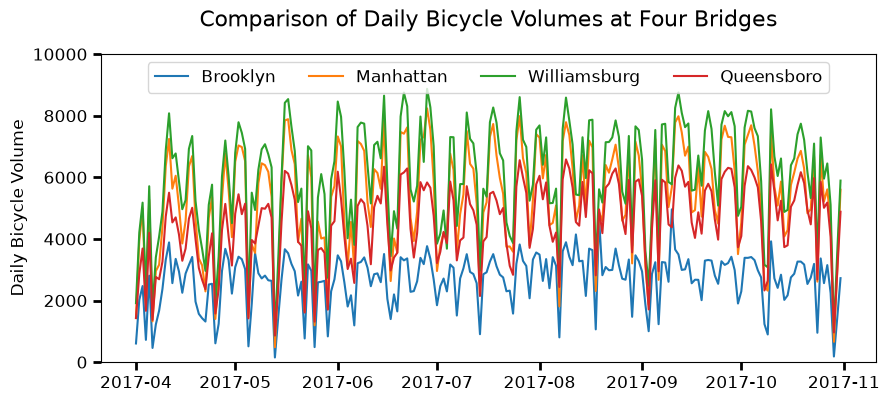

In [7]:
## A chart showing the time series plots of daily bicycle counts at the four bridges

# Define a DataFrame consisting of four time Series of daily counts at four bridges
df = NY_bicycle_ts[['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']]

# Create a line chart
plt.figure(figsize=(10,4)) # Define the plot size by width and height in inches
plt.plot(df) #The plot() method creates a line chart. df's index is used as the x-axis

# plt.xlabel() and plt.ylabel() specify the axis labels 
plt.ylabel('Daily Bicycle Volume',
           fontsize=12
          ) 
plt.xlabel('') 

# plt.tick_params() specifies parameters for axis ticks
plt.tick_params(axis='both',
                labelsize=12,
                direction='out', #Place ticks outside the chart
                length=6, # length of the ticks
                width=2, # width of the ticks
                colors='k', # tick color
                labelcolor = 'k', # tick label color
                #grid_color='k', # Set the gridline color.
                grid_alpha=0.5) # Set the transparency of gridlines.

plt.ylim(ymax=10000,ymin=0)

plt.legend(['Brooklyn','Manhattan','Williamsburg','Queensboro'], 
           loc='upper center',
           ncol=4,
           bbox_to_anchor=(0.5,1),
           fontsize=12)

plt.title('Comparison of Daily Bicycle Volumes at Four Bridges',fontsize=16,pad=20)
plt.show();

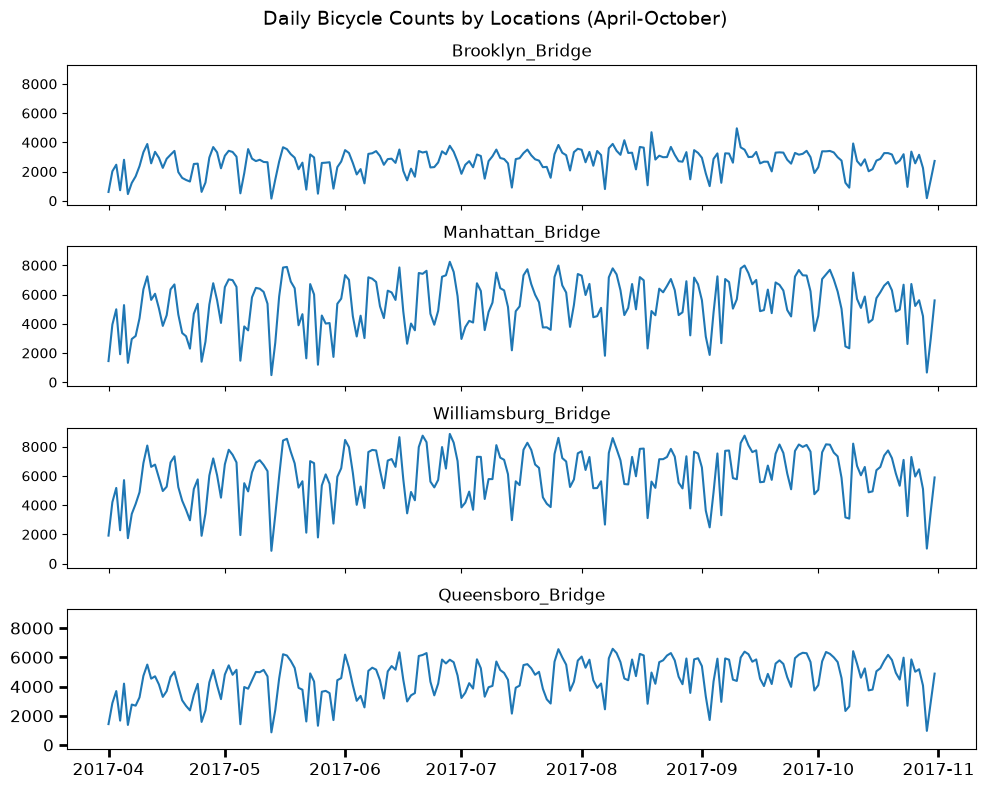

In [8]:
# a chart with four subplots that each showing the trend line of daily bicycle counts at a location

df = NY_bicycle_ts[['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']]

# Define a chart with subplots using plt.subplots(rows, columns, ...)
fig, axs = plt.subplots(4,1, 
                        sharey=True, #subplots share y-axis
                        sharex=True, # subplots share x-axis
                        tight_layout=True, 
                        figsize=(10,8))

# Draw the subplots one by one
for i,col in enumerate(axs):
    axs[i].plot(df.iloc[:,i]) # Plot a line chart for column i in the DataFrame df.
    axs[i].set_title(df.columns[i]) # set_title() defines the title for an Axes object. Here, we use the column name as the subplot title.


# Add a centered title to the figure.
plt.suptitle('Daily Bicycle Counts by Locations (April-October)',
             fontsize=14
            )

# Customize ticks if needed.
plt.tick_params(axis='both',
                labelsize=12,
                direction='out', 
                length=6, 
                width=2,
                colors='k',
                labelcolor = 'k',
                #grid_color='k', 
                grid_alpha=0.5)



# Define ranges of y-axis. The four time series are at different magnitudes. 
# We could manually define the range for y-axis if we are not satisfied with the automatically defined range
#plt.ylim(ymax=14000, ymin=0)

# Display all open figures
plt.show(); 

### Area Chart

An area chart is a **stacked line chart** with the areas between lines filled with color. It is useful when you want to show both the total volume and how different groups contribute to that total.

We can use `matplotlib.pyplot.stackplot()` to create this type of plot.

Suggested exercise:
1. Create an area chart that shows daily total bicycle count over time, with counts at different locations represented by different colored areas.


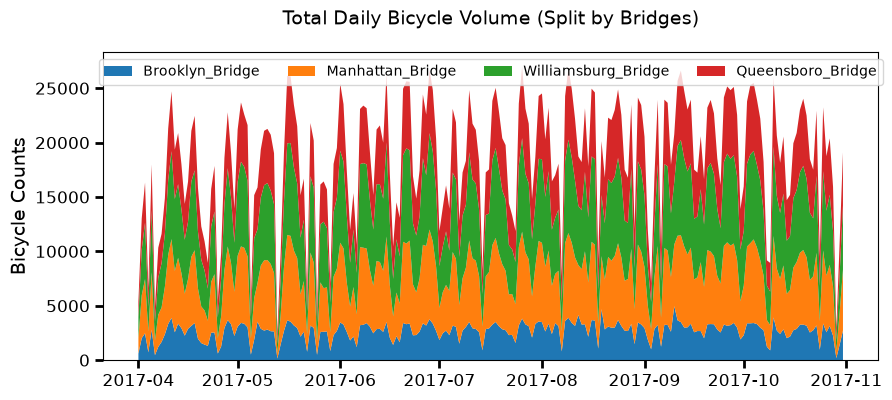

In [9]:
# Generate a stacked trend line that shows stacked daily volumes over time
# We use matplotlib.pyplot.stackplot(x, y)

df=NY_bicycle_ts[['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']]

plt.figure(figsize=(10,4))
plt.stackplot(df.index, # X is 1 x M
               df.T, # Y must be N x M. Here, the transpose operator is important
              labels=df.columns) # labels for the stacked series

plt.ylabel('Bicycle Counts',
           fontsize=14
          )
plt.xlabel('')


plt.tick_params(axis='both',
                labelsize=12,
                direction='out', 
                length=6, 
                width=2,
                colors='k',
                grid_color='k', 
                grid_alpha=0.5)

# Because we put four series in a single plot, it is important to use a legend to distinguish them
plt.legend(df.columns, # Use column names as the labels for each series. We can also directly define a list like ['Brooklyn','Manhattan','Williamsburg','Queensboro']
           loc='upper center', # location of the legend
           ncol=4, # layout of the labels. Here, this means four columns
           #bbox_to_anchor=(0.5,1), # It defines the relative location of the legend box  
           fontsize=10)

plt.title('Total Daily Bicycle Volume (Split by Bridges)',
          fontsize=14,
          pad=20 # Add space in points between the plot title and the plot
         )

plt.show();

### Histogram

A histogram shows the distribution of observations across a range of non-overlapping bins. Use it to examine the shape, center, spread, and unusual values in a numerical variable.

`matplotlib.pyplot.hist()` can be used to create a histogram.

Suggested exercises:
1. Create a histogram to show the distribution of `Total`.
2. [Optional] Approximate `Total` with a normal distribution. Visualize the fitted distribution and overlay it on the histogram.
3. Create a plot with four subplots arranged as a 2x2 matrix. Each subplot should be a histogram showing the distribution of daily bicycle counts at one location.


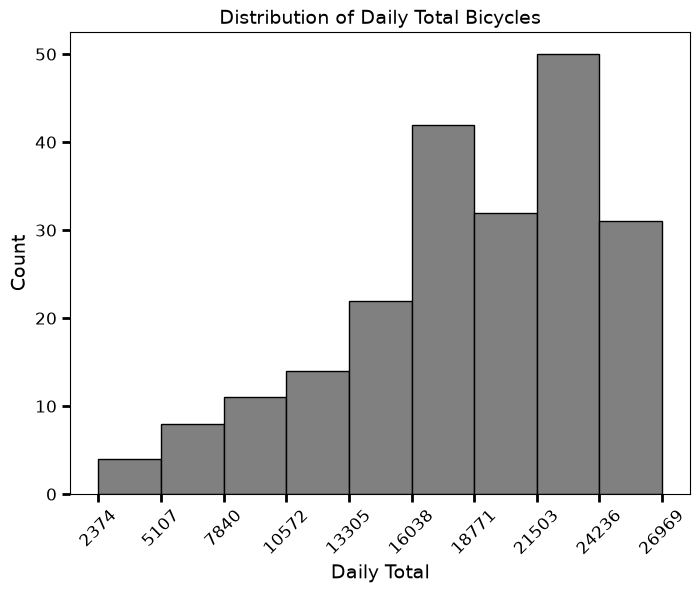

In [10]:
# Generate a histogram to show the distribution of daily bicycle counts

plt.figure(figsize=(8,6))

counts, bins, patches = plt.hist(NY_bicycle_ts.Total,  #  column for visualization
                                 bins=9, # the number of bins
                                 density = False, # False - show count, True - normalized to show percentage
                                 cumulative = False, # False - probability distribution, True - cumulative distribution
                                 facecolor='grey', # color of bins
                                 edgecolor='black') # color of bin edges

plt.ylabel('Count',fontsize=14)
plt.xlabel('Daily Total',fontsize=14)

plt.tick_params(axis='both',
                labelsize=12,
                direction='out', 
                length=6, 
                width=2,
                colors='k',
                grid_color='k', 
                grid_alpha=0.5)

#in this example, xticks are set to be the boundaries of bins and they are rotated by 45 degrees
plt.xticks(ticks=bins,
           rotation=45
          ) 

#plt.ylim(ymax=60, ymin=0)

plt.title('Distribution of Daily Total Bicycles',fontsize=14)

plt.show();

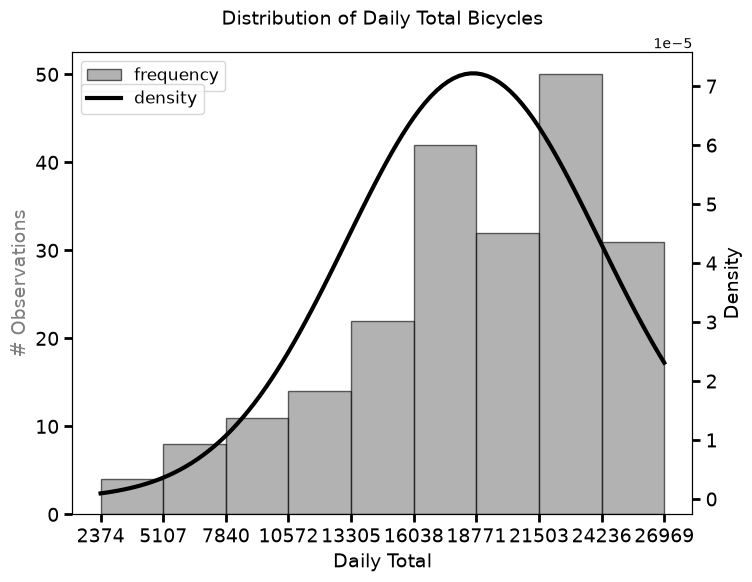

In [11]:
# Fit a normal distribution to "Total" and overlay it with the histogram. 

fig, ax1 = plt.subplots(figsize=(8,6))
ax2 = ax1.twinx() # Create a twin Axes sharing the x-axis. This is a critical step for creating a chart with two y-axes

# Create a histogram for column "Total" on ax1
counts, bins, patches = ax1.hist(NY_bicycle_ts.Total, 
                                 bins=9,
                                 density = False,
                                 cumulative = False,
                                 facecolor='grey',
                                 edgecolor='black',
                                 alpha=0.6)

ax1.set_ylabel('# Observations',fontsize=14,color="grey")
ax1.set_xlabel('Daily Total',fontsize=14)

ax1.tick_params(axis='both',
                labelsize=14,
                direction='out', 
                length=6, 
                width=2,
                colors='k',
                grid_color='k', 
                grid_alpha=0.5)

ax1.legend(['frequency'], 
           loc='upper left',
           ncol=2,
           bbox_to_anchor=(0,1),
           fontsize=12)

# fit the normal distribution to "Total" and visualize the fitted normal distribution on ax2

from scipy.stats import norm #import the normal distribution module
mu, std = norm.fit(NY_bicycle_ts.Total) # Fit a normal distribution for "Total". mu and std are the estimated mean and standard deviation.
xmin = NY_bicycle_ts.Total.min()
xmax = NY_bicycle_ts.Total.max()
x = np.linspace(xmin, xmax, 100) # Define an array of x values for the fitted normal distribution. Use numpy.linspace(min, max, N) to generate an array with N evenly spaced numbers within a range
p = norm.pdf(x, mu, std) # Use norm.pdf(x, mu, std) to find the probability density on the range of x

ax2.plot(x, 
         p,
         linewidth=3,
         color='black')

ax2.set_ylabel('Density', fontsize=14,color='black')

ax2.tick_params(axis='both',
                labelsize=14,
                direction='out', 
                length=6, 
                width=2,
                colors='k',
                grid_color='k', 
                grid_alpha=0.5)

ax2.legend(['density'], 
           loc='upper left',
           ncol=2,
           bbox_to_anchor=(0,0.95),
           fontsize=12)

# additional set up for the entire chart
plt.xticks(ticks=bins,
           rotation=45
          ) #xticks are set to be the boundaries of bins and they are rotated by 45 degrees

plt.title('Distribution of Daily Total Bicycles',
          fontsize=14,
          pad=20)

plt.show();

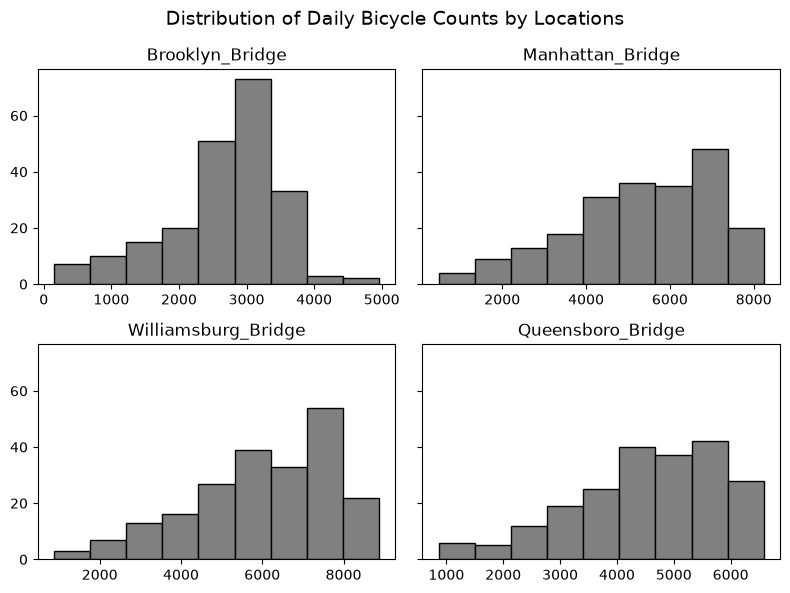

In [12]:
# generate four subplots arranged as a 2 by 2 matrix. 
# Each subplot is a histogram showing the distribution of daily bicycle counts at each location

# matplotlib.pyplot.subplots(nrows,ncolumns) can be used to create a figure of subplots

df=NY_bicycle_ts[['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']]

fig, axs = plt.subplots(2,2, 
                        sharey=True, 
                        sharex=False, # here we do not share x-axis because the data range varies by location 
                        tight_layout=True, 
                        figsize=(8,6))

# Flatten the axs array because axs is a 2x2. After flattening it, the iteration process only needs one index
axs_flat = axs.flatten()

for i, ax in enumerate(axs_flat):
    ax.hist(df.iloc[:, i], 
            bins=9, 
            facecolor='grey', 
            edgecolor='black')
    ax.set_title(df.columns[i])
    

plt.suptitle('Distribution of Daily Bicycle Counts by Locations',
             fontsize=14
            )

plt.show();

### Bar Chart

Bar charts visualize data across one or more categories. They are useful for comparing totals, averages, or other summary values between groups.

`pandas.DataFrame.plot(kind='bar')` and `pandas.DataFrame.plot(kind='barh')` are convenient tools for generating column and horizontal bar charts from DataFrame summary tables, like the tables we created in the previous learning module.

`matplotlib.pyplot.table()` can be used to add a table to a chart.

Suggested exercises:
1. Generate a stacked column chart that shows the total bicycle counts at each bridge over the seven-month period. Split the counts by weather type.
2. Add a table to the bottom of the chart created in step 1. [Hint: use `matplotlib.pyplot.table()`.]
3. Create a clustered, or unstacked, column chart that shows the mean daily bicycle volume by location and weather type. Columns at the same location should be clustered as a subgroup.
4. Create a stacked bar chart that shows the total bicycle counts at each bridge over the seven-month period. Split the counts by weather type. Order the bars in descending order of total bicycle count. [Hint: use `sort_values()` to order the bars.]


Weather                   N       R      T
Brooklyn_Bridge      399657  136437  37435
Manhattan_Bridge     794366  272356  77212
Williamsburg_Bridge  885226  322814  87015
Queensboro_Bridge    662085  246144  65576


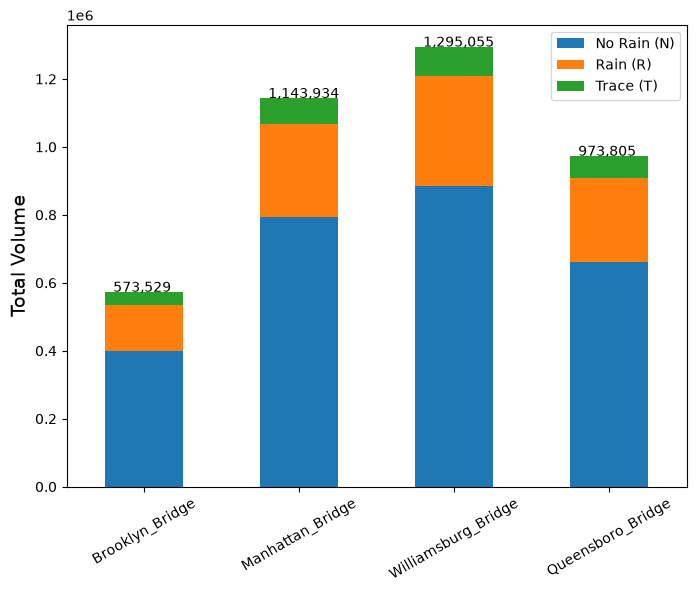

In [13]:
# generate a (vertical) bar chart using plot(kind='bar')
df = NY_bicycle_ts.groupby('Weather')[['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']]

my_table = df.sum().T # This generates a summary table with bridges as rows and weather types as columns
print(my_table)

ax = my_table.plot(kind='bar', # Use DataFrame.plot(kind='bar') to display a bar chart. Each row of the summary table is displayed as a vertical bar
                   stacked=True, # stacked=True returns a stacked bar chart
                   figsize=(8,6)
                  ) 

plt.xticks(rotation=30)

plt.legend(['No Rain (N)','Rain (R)','Trace (T)'], # columns of the summary table are weather types in alphabetical order
           loc='best',
           ncol=1, # Display labels as a column
           fontsize=10)

plt.ylabel('Total Volume',
           fontsize=14)


# Use matplotlib.pyplot.annotate() to show the label of total bicycle count at each bridge
for i in range (4):
    plt.annotate('{:,}'.format(my_table.sum(axis=1).iloc[i]), #my_table.sum(axis=1) calculates the total bicycle count at each bridge 
                 (i-0.2, my_table.sum(axis=1).iloc[i]+40), # location to print the data label
                 fontsize=10)
    

plt.show();

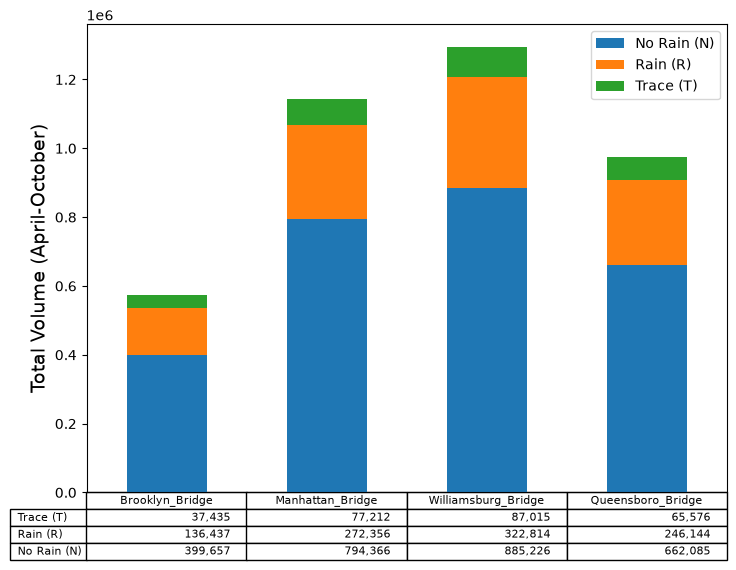

In [14]:
# Combining a bar chart with a summary table can show both detailed numbers and visual comparisons.

#  Let's add a table at the bottom of the stacked chart 

# generate bar chart with an embedded table

# Get the data needed
df=NY_bicycle_ts.groupby('Weather')[['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']]

my_table=df.sum().T

# Create the bar chart
my_table.plot(kind='bar',
              stacked=True,
              figsize=(8,6))
plt.xticks([]) # Hide x-ticks because the table provides the category labels.
plt.legend(['No Rain (N)','Rain (R)','Trace (T)'], 
           loc='best',
           ncol=1,
           fontsize=10)
plt.ylabel('Total Volume (April-October)',fontsize=14)


# Add a table at the bottom of the axes
data = my_table.T.map('{:,}'.format) # Define data in the table

# matplotlib.pyplot.table() can display a table
add_table = plt.table(cellText=np.flipud(data), # np.flipud() flips row order along the first axis. This matches the table order with the stacked-bar order.
                      rowLabels=['Trace (T)','Rain (R)','No Rain (N)'], # Define the row labels of the table.
                      colLabels=data.columns.to_list(), # Define the column labels of the table.
                      loc='bottom',
                     ) 

add_table.set_fontsize(16) # adjust the font size of the table

# Adjust layout to make room for the table:
plt.subplots_adjust(left=0.1, bottom=0.1)

plt.show();


Weather                        N            R            T
Brooklyn_Bridge      3050.816794  1977.347826  2673.928571
Manhattan_Bridge     6063.862595  3947.188406  5515.142857
Williamsburg_Bridge  6757.450382  4678.463768  6215.357143
Queensboro_Bridge    5054.083969  3567.304348  4684.000000


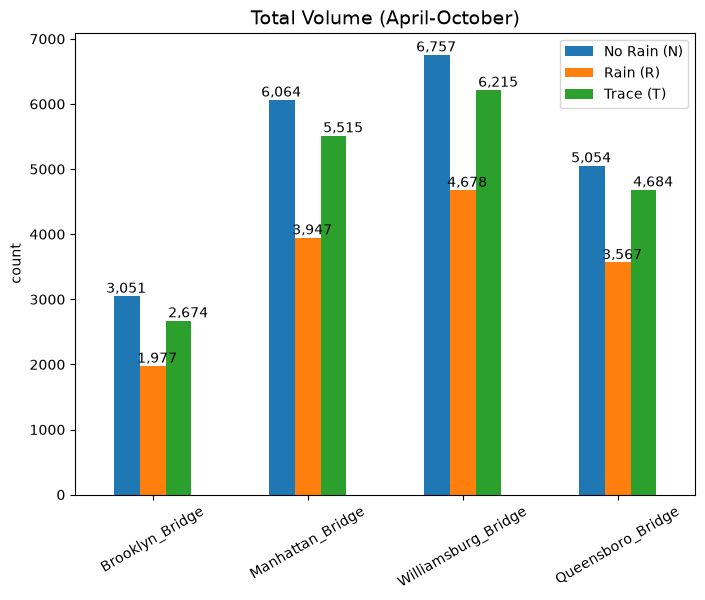

In [15]:
# Create a clustered, or unstacked, column chart showing mean daily bicycle volume by location and weather type.

df=NY_bicycle_ts.groupby('Weather')[['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']]

my_table = df.mean().T

ax = my_table.plot(kind='bar',
                   stacked=False, # stacked=False returns clustered bar chart

                   figsize=(8,6)) 
print(my_table)

plt.xticks(rotation=30)

plt.legend(['No Rain (N)','Rain (R)','Trace (T)'], 
           loc='best',
           ncol=1,
           fontsize=10)

plt.title('Total Volume (April-October)',fontsize=14)
plt.ylabel('count')

# print data label on the top of each bar
for i in range (my_table.shape[0]):
    for j in range (my_table.shape[1]):
        plt.annotate('{:,.0f}'.format(my_table.iloc[i,j]),
                     (i-0.3+0.2*j, # x-axis location
                      my_table.iloc[i,j]+50)) # y-axis location

plt.show();

         Brooklyn_Bridge  Manhattan_Bridge  Williamsburg_Bridge  \
Weather                                                           
N                 399657            794366               885226   
R                 136437            272356               322814   
T                  37435             77212                87015   

         Queensboro_Bridge  
Weather                     
N                   662085  
R                   246144  
T                    65576  
Brooklyn_Bridge         573529
Queensboro_Bridge       973805
Manhattan_Bridge       1143934
Williamsburg_Bridge    1295055
dtype: int64


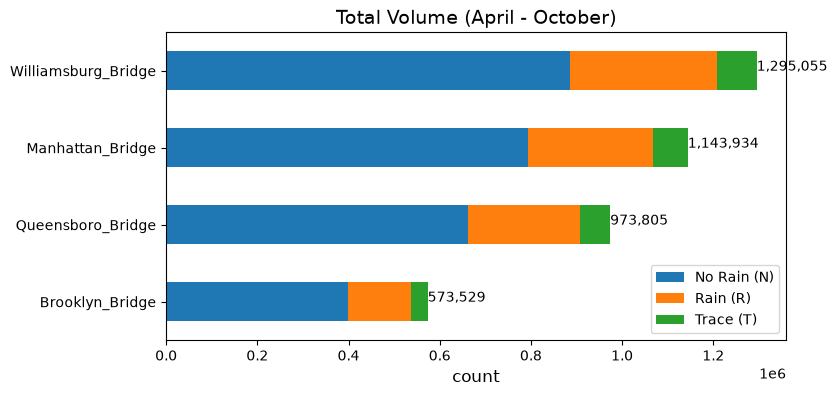

In [16]:
# Horizontal bar chart is commonly used to visualize ordered data.

# Create a (horizontal) bar chart using plot(kind='barh'). 

# Define the table to be visualized
df = NY_bicycle_ts.groupby('Weather')[['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']]
my_table = df.sum() 
print(my_table)

# re-order the table according to the row sums in ascending order 
the_table=my_table[my_table.sum().sort_values(ascending=True).index]
print(the_table.sum())

# plot stacked horizontal bar chart
the_table.T.plot(kind='barh', # horizontal bar chart
                 stacked=True, # stacked
                 figsize=(8,4)
                )
plt.title('Total Volume (April - October)', 
           fontsize=14
          )

plt.xlabel('count',
          fontsize = 12
          )

plt.legend(['No Rain (N)','Rain (R)','Trace (T)'], 
           loc='best',
           ncol=1,
           fontsize=10)

# Add the cumulative amount to each stacked bar to each bar
for i in range(my_table.shape[1]):
    # Use matplotlib.pyplot.text(x, y, s) to show the data labels
    plt.annotate('{:,}'.format(the_table.sum().iloc[i]),
                (the_table.sum().iloc[i],i)
                )
plt.show();

### Pie Chart

Use a pie chart to show the proportional contributions of a categorical variable. Pie charts work best when there are only a few categories and the goal is to compare parts of a whole.

`matplotlib.pyplot.pie()`

Suggested exercise:
1. Create a pie chart to show the proportions of total bicycle counts at each of the four bridges. Label each slice with the location and percentage of total bicycle counts. Pull the `Brooklyn_Bridge` slice out slightly.


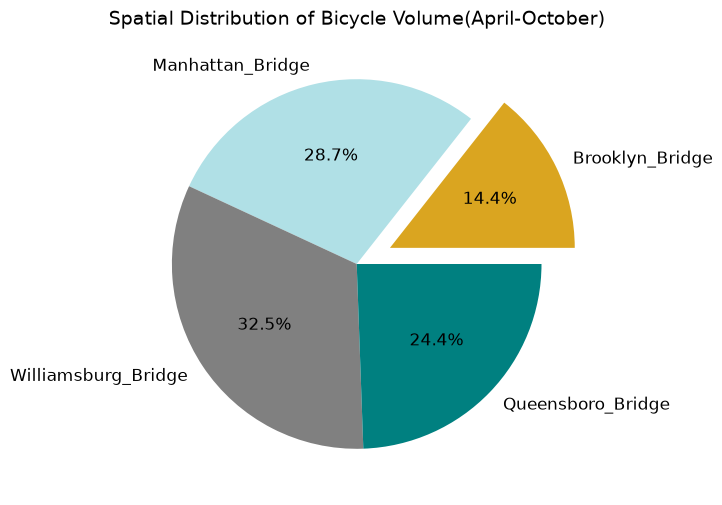

In [17]:
# Use a pie chart to show the proportions of total bicycle counts by location


df=NY_bicycle_ts[['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']]

fig = plt.figure(figsize=(6,6))
patches, texts, autotexts= plt.pie(df.sum(), 
                                   labels=df.columns,
                                   explode=[0.2,0,0,0],  # To pull a slice out a little bit, use explode to define it
                                   colors=['goldenrod','powderblue','grey','teal'], # a list defining the colors for individual slices
                                   autopct='%1.1f%%', #percentage format
                                   textprops={'fontsize': 12}
                                  )

for text in texts:
    text.set_fontsize(12)  # Change the font size to 12

plt.title('Spatial Distribution of Bicycle Volume(April-October)', 
          fontsize=14, 
          loc='center')

plt.show();


### Box Plots

A boxplot shows the distribution of a variable using quartile measures. It is helpful for comparing medians, variability, and potential outliers across groups.

`matplotlib.pyplot.boxplot()`

Suggested exercise:

1. Create a chart that shows four boxplots of daily bicycle counts at the four bridges.


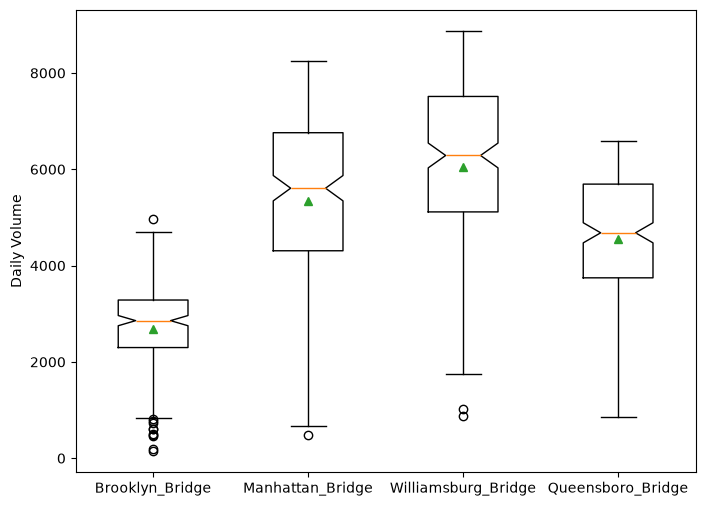

In [18]:
# generate a boxplot for each of multiple numerical variables

df = NY_bicycle_ts[['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']]

plt.figure(figsize=(8,6))

# Use matplotlib.pyplot.boxplot()
plt.boxplot(df,
            notch=True, # notch at median
            tick_labels=df.columns, # Display labels for boxplots
            showcaps=True, # Display the caps on the ends of whiskers. 
            showfliers=True, # show outliers beyond the whiskers.
            showmeans=True # Display mean 
           ) 

plt.ylabel('Daily Volume')

plt.show();

### Scatter Chart

A scatter plot visualizes the relationship between two numerical variables. It is useful for examining association, trend direction, strength, and unusual observations.

`matplotlib.pyplot.scatter()`  
`pandas.plotting.scatter_matrix()`

Suggested exercises:
1. Create a scatter chart to examine whether daily bicycle count and temperature are correlated. Since the dataset has both daily high and low temperatures, create two overlapping scatter plots. Differentiate them by color.
2. Add three histograms to the chart in step 1. Two histograms should be overlaid at the top to show the marginal distributions of `High_Temp_F` and `Low_Temp_F`. The third histogram should be on the right side of the scatter plot to show the marginal distribution of `Total`.
3. Create a scatter chart to examine whether daily bicycle counts at the Manhattan Bridge and Brooklyn Bridge are correlated. Color the observations according to `High_Temp_F`.
4. Create a scatter chart matrix that summarizes the relationship between each pair of numerical variables in the dataset.


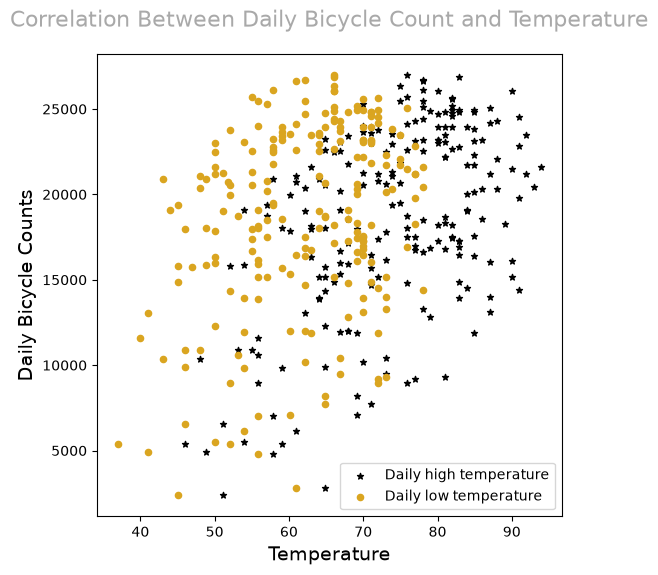

In [19]:
# Use scatter plot to show the relationship between daily bicycle counts with temperature

# In this example, we overlay two scatter plots together. They respectively show the correlation between "Total" and high/low temperature
# we use different symbols to differentiate them

plt.figure(figsize=(6,6))

plt.scatter(NY_bicycle.High_Temp_F, # x
            NY_bicycle.Total, # y
            color='black', # color of the symbol for data points
            marker='*', # type of symbol for representing data points
            s=20 # size of  the symbol
           )

plt.scatter(NY_bicycle.Low_Temp_F,
            NY_bicycle.Total,
            color='goldenrod',
            marker='o',
            s=20)

plt.legend(['Daily high temperature','Daily low temperature'])

plt.xlabel('Temperature',
           fontsize=14
          )
plt.ylabel('Daily Bicycle Counts',
           fontsize=14
          )

plt.title('Correlation Between Daily Bicycle Count and Temperature',
          fontsize=16, 
          color='darkgrey',
          pad=20
         )

plt.show();

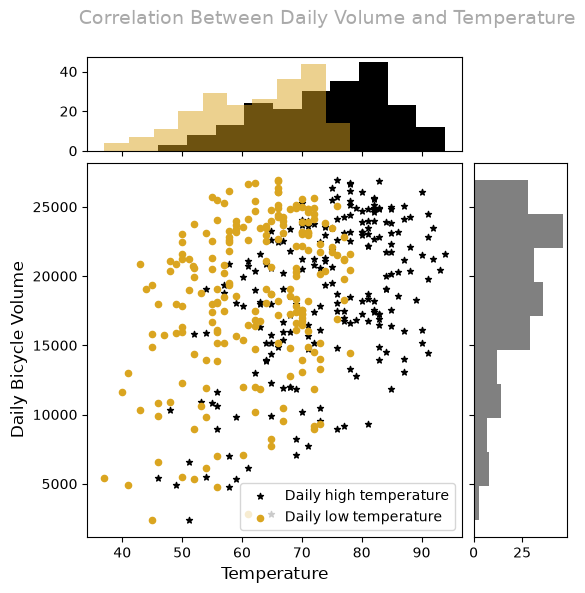

In [20]:
# Project scatter plots onto the x- and y-axes to show marginal distributions.

# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))

# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal axes and the main axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2, # two rows, two columns
                      width_ratios=(4, 1), height_ratios=(1, 4), # Defines the relative widths of the columns, and heights of the rows
                      left=0.1, right=0.9, bottom=0.1, top=0.9, #Define the extent of the subplots as a fraction of figure width or height.
                      wspace=0.05, hspace=0.05 # space between subplots
                     )

# Create the Axes.
ax = fig.add_subplot(gs[1, 0]) # ax is the axis object for the scatter plots. It is at the bottom left(i.e., [1,0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax) # ax_histx is the axis object for the histograms along x-axis. It is at the top left (i.e. [0,0])
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax) # ax_histy is the axis object for the histograms along y-axis. It is at the bottom right (i.e. [1,1])
ax_histx.tick_params(axis="x", 
                     labelbottom=False
                    ) # Remove ticks at the bottom
ax_histy.tick_params(axis="y", 
                     labelleft=False
                    ) # Remove ticks on the left

# scatter plot between Total and High_Temp_F
ax.scatter(NY_bicycle_ts.High_Temp_F,
           NY_bicycle_ts.Total,
           color='black',
           marker='*',
           s=20)

# scatter plot between Total and Low_Temp_F
ax.scatter(NY_bicycle_ts.Low_Temp_F,
           NY_bicycle_ts.Total,
           color='goldenrod',
           marker='o',
           s=20)

# histogram of High_Temp_F along x-axis
ax_histx.hist(NY_bicycle_ts['High_Temp_F'],
              alpha=1,
              color='black'
             )

# histogram of Low_Temp_F along y-axis
ax_histx.hist(NY_bicycle_ts['Low_Temp_F'],
              alpha=0.5,
              color='goldenrod'
             )

# histogram of Total along y-axis
ax_histy.hist(NY_bicycle_ts['Total'], 
              orientation='horizontal',
              color='grey'
             )


# Add additional elements to the entire plot
ax.legend(['Daily high temperature','Daily low temperature'])
ax.set_xlabel('Temperature',
              fontsize=12
             )
ax.set_ylabel('Daily Bicycle Volume',
              fontsize=12
             )
plt.suptitle('Correlation Between Daily Volume and Temperature',
             fontsize=14, 
             color='darkgrey'
            )
plt.show();

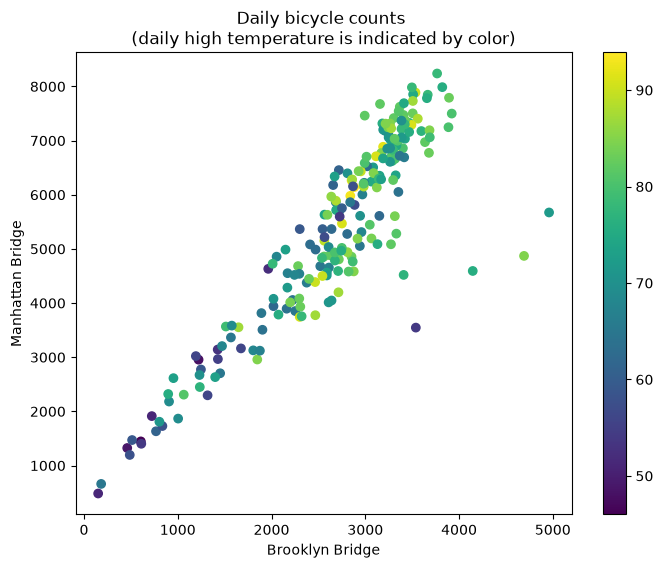

In [21]:
# Visualize the relationship between daily bicycle counts at two locations. Use color to indicate the day's high temperature.

plt.figure(figsize=(8,6))
plt.scatter(x=NY_bicycle_ts.Brooklyn_Bridge,
            y=NY_bicycle_ts.Manhattan_Bridge,
            c=NY_bicycle_ts.High_Temp_F,
            cmap='viridis') # plt.scatter() returns a scatter plot of two numerical columns to show their association. The color is the 'High_Temp_F' value of each data point
plt.xlabel('Brooklyn Bridge') 
plt.ylabel('Manhattan Bridge')
plt.colorbar() # displays the colorbar
plt.title('Daily bicycle counts \n (daily high temperature is indicated by color) ')
plt.show();

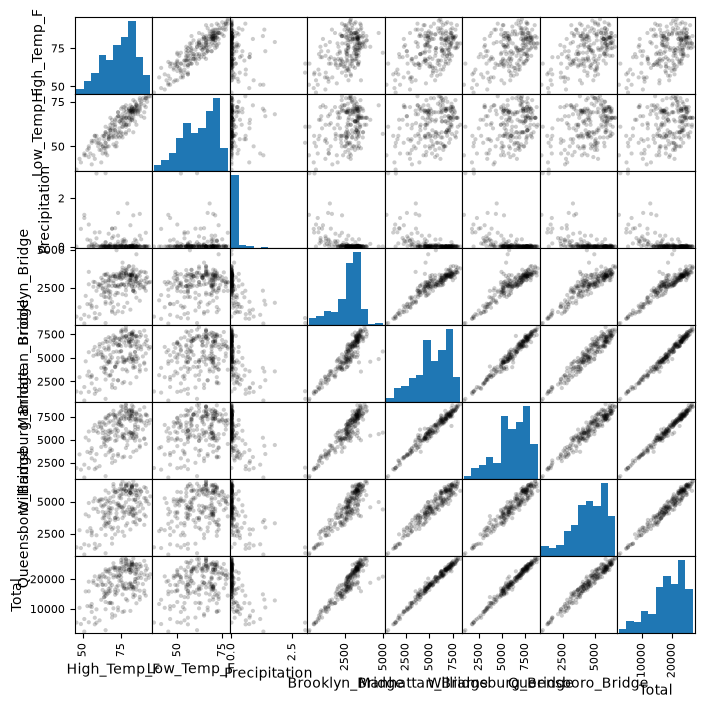

In [22]:
# to generate scatter plot matrix, it is convenient to use pandas.plotting.scatter_matrix()

pd.plotting.scatter_matrix(NY_bicycle_ts,
                           alpha=0.2,
                           figsize=(8,8),
                           color='black') #pd.plotting.scatter_matrix() generates the matrix of scatter plots
plt.show();

### Bubble Chart

A bubble chart extends a scatter plot by using bubble size to represent a third numerical variable.

Use `matplotlib.pyplot.scatter()` to create a bubble chart.

Suggested exercise:
1. Calculate the mean, standard deviation, and minimum daily bicycle count by location. Visualize the result using a bubble chart: the x-axis is standard deviation, the y-axis is mean, and bubble size represents the minimum.


      Brooklyn_Bridge  Manhattan_Bridge  Williamsburg_Bridge  \
std             854.7            1746.5               1755.8   
mean           2680.0            5345.5               6051.7   
min             151.0             484.0                874.0   

      Queensboro_Bridge  
std              1306.9  
mean             4550.5  
min               865.0  


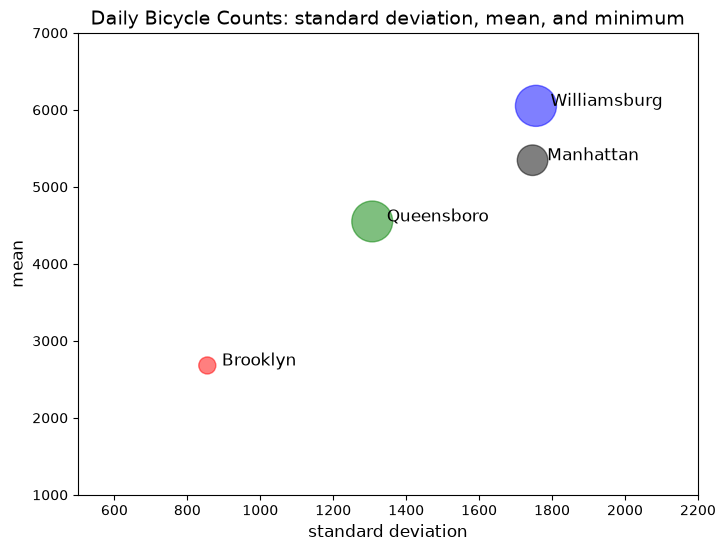

In [23]:
# visualize the standard deviation, mean, and minimum at different locations using a bubble chart
df=NY_bicycle_ts[['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']]
df_B=df.agg(['std','mean','min'])
print(df_B.round(1))

plt.figure(figsize=(8,6))
# Create the bubble plot by using standard deviation as the x-axis, mean as the y-axis, and minimum as the bubble size
plt.scatter(df_B.iloc[0,:],
            df_B.iloc[1,:],
            df_B.iloc[2,:],
            color=['red','black','blue','green'],
            alpha=0.5
           )

plt.axis([500, 2200, 1000,7000]) # Define the range of axes

plt.xlabel('standard deviation',fontsize=12)
plt.ylabel('mean', fontsize=12)

bridges=['Brooklyn','Manhattan','Williamsburg','Queensboro']

# Add a label to each bubble
for i in range(4):
    plt.annotate(bridges[i], 
                 (df_B.iloc[0, i]+40, df_B.iloc[1, i]), 
                 fontsize=12)

plt.title('Daily Bicycle Counts: standard deviation, mean, and minimum',fontsize=14)
plt.show();

### Heat Map

A heat map uses color to represent values in a two-dimensional table, such as rows by columns.

Use `matplotlib.pyplot.pcolor()` to create a heat map.

Suggested exercise:
1. Use a heat map to show the mean daily bicycle volume by day of week and bridge. Include a color bar so readers can interpret the values.


           Brooklyn  Manhattan  Williamsburg  Queensboro
Day                                                     
Monday       2615.1     5449.1        5974.9      4500.1
Tuesday      2773.1     5991.9        6524.4      4964.4
Wednesday    2998.3     6439.9        7144.5      5308.8
Thursday     2944.3     6167.7        6940.0      5233.0
Friday       2588.6     5255.6        6107.9      4620.8
Saturday     2367.9     3983.4        4957.4      3739.1
Sunday       2488.8     4189.6        4778.2      3536.0


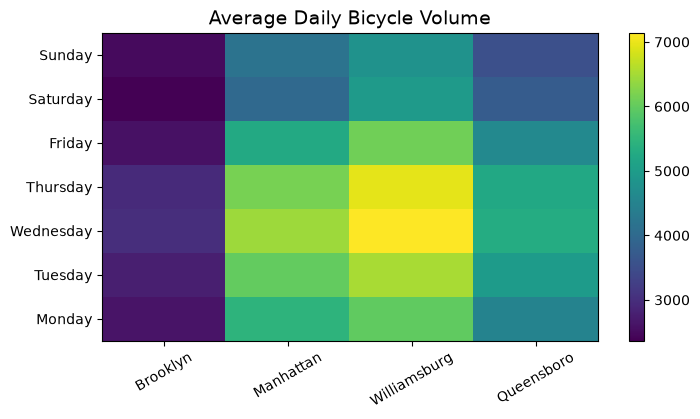

In [24]:
## generate a heat map using plt.pcolor(x,y,values to color)

df=NY_bicycle_ts[['Day','Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']]

# Rename columns for clearer display labels.
df.columns = ["Day", "Brooklyn", "Manhattan", "Williamsburg", "Queensboro"]

#create a matrix that shows the mean daily volume at each location and each day of week
df_B=df.groupby('Day').mean()
print(df_B.round(1))

plt.figure(figsize=(8,4))
plt.pcolor(df_B,
           cmap='viridis'
          )

plt.yticks(np.arange(0.5, len(df_B.index), 1), 
           df_B.index
          ) # Define y ticks that are the index values
plt.xticks(np.arange(0.5, len(df_B.columns), 1), 
           df_B.columns,
           rotation=30
          ) # Define x ticks that are the four locations

plt.title('Average Daily Bicycle Volume',fontsize=14)

plt.colorbar() # show a color bar to indicate the values in the table

plt.show();

## Data Visualization using plotly

https://plotly.com/

In this section, we illustrate a few examples of data visualization using plotly. These examples supplement Matplotlib by showing how interactive charts can support data exploration.


### Box plot

Using plotly to generate box plots is convenient. Given a dataset, we identify the numerical variable whose distribution we want to show and one or more categorical variables used to compare groups.

`plotly.express.box()`

Suggested exercises:
1. Create a chart that shows four boxplots of daily bicycle counts at the four bridges.
2. Create a chart that shows 28 boxplots of daily bicycle counts, where each boxplot represents one bridge on one day of the week. Cluster the boxplots by location.


In [25]:
# plotly is a package for interactive data visualization: https://plotly.com/
#import plotly.express as px

# pandas.melt() converts a wide table into a long table. Here, we combine bicycle-count columns into two columns: location and count.
df = pd.melt(NY_bicycle_ts,
             id_vars=['Day','High_Temp_F'], 
             value_vars=['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']
            )
df.columns=['Day','Temperature','Bridge','Count']
print(df)

# Draw boxplots.
plt.figure(figsize=(8,6))
fig = px.box(df, # Define the data table to visualize with boxplots.
       x='Bridge', # Define the categorical variable
       y='Count', # Define the numerical variable for showing boxplots
       points='all', # Display the raw data points if we choose to do so
       notched=True
      )


fig.update_xaxes(title_text=' ') # Modify the x-axis label.
fig.show();

# when we move the mouse on the plots, detailed information is displayed. plotly generates charts highly interactive with users

           Day  Temperature             Bridge  Count
0     Saturday         46.0    Brooklyn_Bridge    606
1       Sunday         62.1    Brooklyn_Bridge   2021
2       Monday         63.0    Brooklyn_Bridge   2470
3      Tuesday         51.1    Brooklyn_Bridge    723
4    Wednesday         63.0    Brooklyn_Bridge   2807
..         ...          ...                ...    ...
851     Friday         62.1  Queensboro_Bridge   5181
852   Saturday         68.0  Queensboro_Bridge   4069
853     Sunday         64.9  Queensboro_Bridge    965
854     Monday         55.0  Queensboro_Bridge   2924
855    Tuesday         54.0  Queensboro_Bridge   4883

[856 rows x 4 columns]


<Figure size 800x600 with 0 Axes>

In [26]:
# Consider boxplots across multiple categorical variables.
df = pd.melt(NY_bicycle_ts,
             id_vars=['Day','High_Temp_F'], 
             value_vars=['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']
            )
df.columns=['Day','Temperature','Bridge','Count']
df.head()

plt.figure(figsize=(12,6))
fig = px.box(df,
       x='Bridge',
       y='Count',
       points='all',
       color='Day', # Use color to further split plots by "Day"
       notched=True
      )

fig.update_xaxes(title_text=' ') # Updating x-axis label
fig.show();

<Figure size 1200x600 with 0 Axes>

### 2D Contour Chart


`plotly.graph_objects.Histogram2dContour(x, y)` uses a 2D contour to show the distribution of observations across two variables. This can reveal dense regions that may be difficult to see in a scatter plot alone.

Suggested exercises:
1. Use a 2D contour chart to visualize the distribution of observations for `High_Temp_F` and `Total`.
2. Combine a scatter chart, 2D contour, and side histograms to visualize the joint and marginal distributions of `High_Temp_F` and `Total`.


In [27]:
# import the graph_objects module from plotly
#import plotly.graph_objects as go 

In [28]:
fig = go.Figure(
    go.Histogram2dContour(
        x = NY_bicycle_ts['High_Temp_F'],
        y = NY_bicycle_ts['Total'],
        #ncontours = 12, Sets the maximum number of contour levels. 
        colorscale = 'Blues'
    ))

fig.update_layout(xaxis_title='Daily Highest Temperature (F)',
                  yaxis_title='Daily Bicycle Total',
                  height=600,
                  width=600
                 )

fig.show();

In [29]:
#  Histogram2dContour + Scatter + Histogram 

x=NY_bicycle_ts['High_Temp_F']
y=NY_bicycle_ts['Total']

# Create a figure object, and then add different components using .add_trace()
fig = go.Figure()


fig.add_trace(go.Histogram2dContour(
    x=x, # Set the value for the marginal distribution.x-axis
    y=y, # Set the value for the marginal distribution.y-axis
    xaxis = 'x', # Sets a reference between this trace’s x coordinates and a 2D Cartesian x-axis
    yaxis= 'y',  # Sets a reference between this trace’s y coordinates and a 2D Cartesian y-axis  
    colorscale = 'Blues'
))


fig.add_trace(go.Scatter(
        x=x, 
        y=y, # Set the value for the marginal distribution.
        xaxis = 'x', 
        yaxis = 'y',
        mode = 'markers',
        marker = dict(
            color = 'rgba(0,0,0,0.3)',
            size = 5
        )
    ))

# Add distribution of "Total"
fig.add_trace(go.Histogram(
        y=y,  # y is the variable for generating the histogram along y-axis
        xaxis = 'x2', # a new xaxis object for this histogram
        marker = dict(
            color = 'rgba(0,0,0,0.5)'
        )
    ))

# Add distribution of "High_Temp_F"
fig.add_trace(go.Histogram(
        x=x, # x is the variable for generating the histogram along x-axis
        yaxis = 'y2', # a new yaxis object for this histogram
        marker = dict(
            color = 'rgba(0,0,0,0.5)'
        )
    ))


##
fig.update_layout(
    autosize = False,
    xaxis = dict(
        zeroline = False,
        domain = [0,0.85], # segment for xaxis
        showgrid = False
    ),
    yaxis = dict(
        zeroline = False,
        domain = [0,0.85], # segment for yaxis
        showgrid = False
    ),
    xaxis2 = dict(
        zeroline = False,
        domain = [0.85,1], # segment for xaxis2
        showgrid = False
    ),
    yaxis2 = dict(
        zeroline = False,
        domain = [0.85,1], # segment for axis2
        showgrid = False
    ),
    height = 800,
    width = 800,
    bargap = 0, #set bargap to 0 so the bars touch
    hovermode = 'closest', # hover only shows info for the nearest point
    showlegend = False, #suppress the legend globally
    xaxis_title='Daily Highest Temperature (F)',
    yaxis_title='Daily Bicycle Total'
)
##//

fig.show();

### Tree and Sunburst maps

A tree map visualizes **hierarchical data** by using nested rectangles. It is useful when you want to compare parts within a hierarchy.

Suggested exercises:
1. Create a DataFrame that summarizes daily bicycle count in a hierarchical structure: NY / day / bridge.
2. Visualize the hierarchical DataFrame as a tree map. Use color to indicate the average daily high temperature.
3. Visualize the hierarchical DataFrame as a sunburst map. Use color to indicate the average daily high temperature.


In [30]:
# Create a DataFrame that summarizes the daily bicycle counts in a hierarchical structure: NY/Day/Bridge

df = pd.melt(NY_bicycle_ts,
             id_vars=['Day','High_Temp_F'], 
             value_vars=['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']
            )

df.columns=['Day','Temperature','Bridge','Count']
df['Bridge'] = df['Bridge'].str.replace('_Bridge', '', regex=False) # Remove the suffix to simplify values in the "Bridge" column.
df

,Day,Temperature,Bridge,Count
0,Saturday,46.0,Brooklyn,606
1,Sunday,62.1,Brooklyn,2021
2,Monday,63.0,Brooklyn,2470
3,Tuesday,51.1,Brooklyn,723
4,Wednesday,63.0,Brooklyn,2807
...,...,...,...,...
851,Friday,62.1,Queensboro,5181
852,Saturday,68.0,Queensboro,4069
853,Sunday,64.9,Queensboro,965
854,Monday,55.0,Queensboro,2924


In [31]:
# Visualize the hierarchical DataFrame as a tree map. Use color to indicate the average daily high temperature

fig = px.treemap(df, # Define the dataset for creating the tree map.
                 path=[px.Constant('NY'),'Bridge', 'Day'], # The path shows the hierarchy. px.Constant("NY") adds a dummy root level with the same value, 'NY'.
                 values='Count', # Set the size of each leaf.
                 color='Temperature',# Set the color of each leaf.
                 color_continuous_scale='RdBu' # Set the color scale.
                )

fig.show()

In [32]:
# Visualize the hierarchical DataFrame as a sunburst map. Use color to indicate the average daily high temperature

fig = px.sunburst(df,
                  path=[px.Constant('NY'),'Bridge','Day'], # The path shows the hierarchy. px.Constant("NY") adds a dummy root level with the same value, 'NY'.
                  values='Count', # Set the size of each leaf.
                  color='Temperature',# Set the color of each leaf.
                  color_continuous_scale='RdBu' # Set the color scale.
                )

fig.show()

## Data Visualization using Seaborn

### Line Charts

Using `seaborn.relplot()` or `seaborn.lineplot()`, we can create trend lines with error bars or confidence intervals. These uncertainty bands help us judge whether observed differences are large compared with day-to-day variability.

`seaborn.relplot()` can create line charts and other relationship plots.
`seaborn.lineplot()` creates line charts directly.

Suggested exercises:
1. Create a chart with trend lines of daily bicycle counts by day of week and location. Provide a 95% confidence interval for each trend line.
2. Create a chart with trend lines of daily bicycle counts by day of week and location. Provide error bars showing standard deviations.


In [33]:
# seaborn is a module for statistical data visualization: https://seaborn.pydata.org/index.html
#import seaborn as sns 

# Set the plotting theme.
#sns.set_theme(style="ticks")

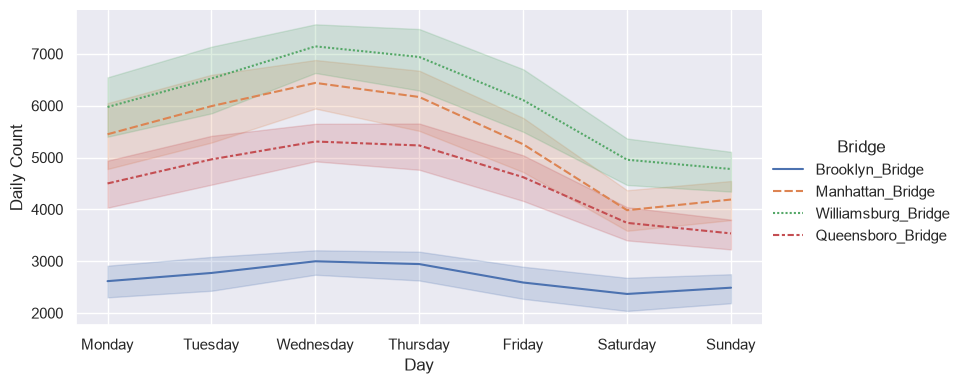

In [34]:
sns.set_theme(rc={'figure.figsize':(12,8)})

df = pd.melt(NY_bicycle_ts,
             id_vars=['Day','High_Temp_F'], 
             value_vars=['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']
            )
df.columns=['Day','Temperature','Bridge','Daily Count']
df.head()

# Use seaborn.relplot() to generate line charts.
sns.relplot(data=df, 
            x="Day", 
            y="Daily Count", 
            kind="line",  # Indicate the type of chart.
            err_style="band",  # Specify the error-bar style. The default is a band; another choice is "bars".
            ci=95,            # Specify the error-bar size. The default is a 95% confidence interval; another choice is "sd".
            hue='Bridge', # Set line color according to bridge.
            style='Bridge', # Set line style according to bridge.
            height=4,  # Set the figure height in inches.
            aspect=2   # width-to-height ratio
           )


plt.show();

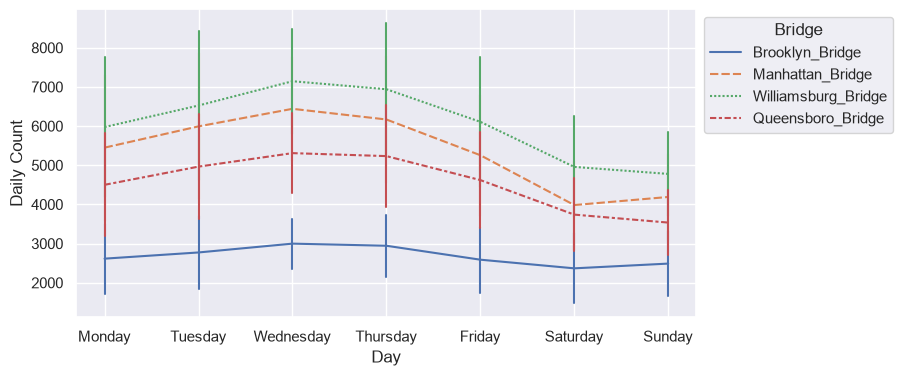

In [35]:
sns.set_theme(rc={'figure.figsize':(8,4)}) # 'rc' means run command. This overrides Matplotlib's configuration.

df = pd.melt(NY_bicycle_ts,
             id_vars=['Day','High_Temp_F'], 
             value_vars=['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']
            )
df.columns=['Day','Temperature','Bridge','Daily Count']
df.head()

ax = sns.lineplot(data=df,
             x='Day',
             y='Daily Count',
             err_style="bars",  # Specify the error-bar style. The default is a band; another choice is "bars".
             ci='sd',            # Specify the error-bar size. The default is a 95% confidence interval; another choice is "sd".
             hue='Bridge',           
             style='Bridge'
            ) 
sns.move_legend(ax, "upper left",bbox_to_anchor=(1, 1))

plt.show();

### Histogram

Seaborn can easily generate a histogram with a kernel density estimate (KDE) of the data distribution.

Suggested exercise:
1. Show the histogram of `Total` with a KDE curve.


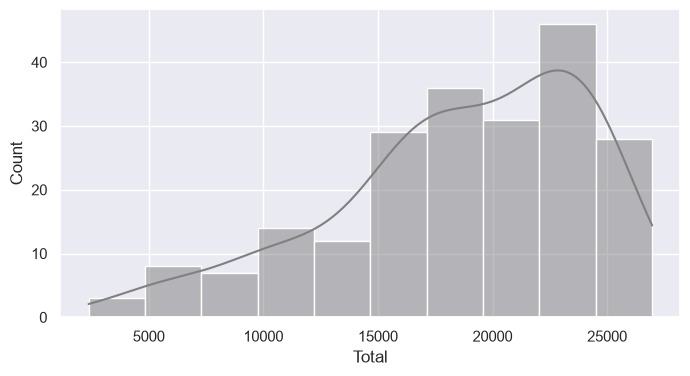

In [36]:
sns.histplot(data=NY_bicycle_ts, 
             x="Total", 
             kde=True, # kde=True will display the kernel density estimate
             color='grey')

sns.set_theme(rc={'figure.figsize':(8,6)}) 

plt.show();

### Bar Charts

Using seaborn, bar and column charts can be created easily.

`seaborn.barplot()`

Suggested exercises:
1. Create a long DataFrame by stacking observations from the four bridges as rows.
2. Create a chart with four subplots arranged as a 2x2 matrix:
    1. A column chart showing the mean daily bicycle count by location.
    2. A bar chart showing the mean daily bicycle count by location.
    3. A clustered column chart showing the mean daily bicycle count by location and weather type. Columns at the same location should be clustered as a subgroup.
    4. A clustered bar chart showing the mean daily bicycle count by location and weather type. Bars at the same location should be clustered as a subgroup.


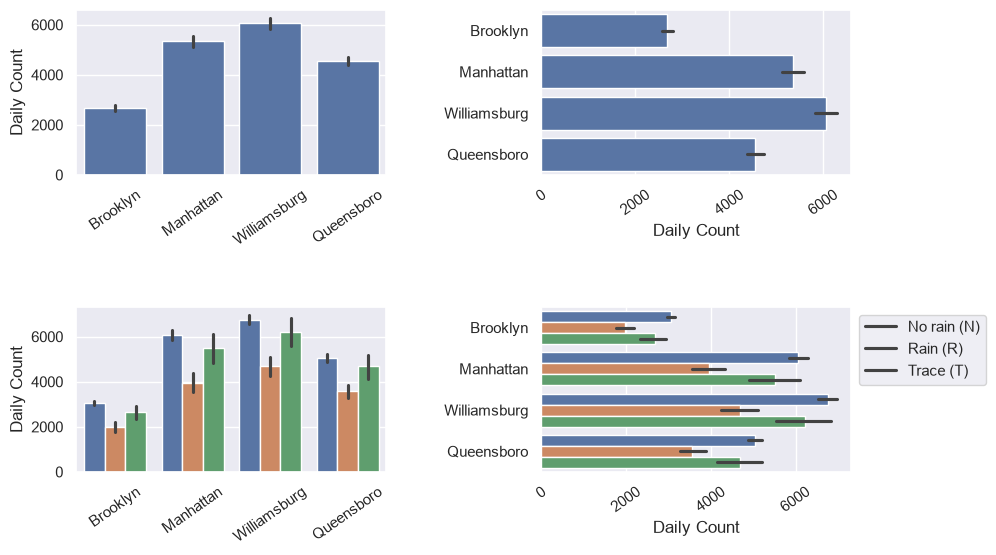

In [37]:
df = pd.melt(NY_bicycle_ts,
             id_vars=['Day','High_Temp_F','Weather'], 
             value_vars=['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']
            )
df.columns=['Day','Temperature','Weather','Bridge','Daily Count']
df['Bridge'] = df['Bridge'].str.replace('_Bridge', '', regex=False) # Remove the suffix to simplify values in the "Bridge" column.
df.head()

fig,ax =plt.subplots(2,2,figsize=(10,6))


# Top-left plot.
# When x is categorical and y is numerical, seaborn creates a vertical bar chart.
sns.barplot(data=df,
            x='Bridge',
            y='Daily Count',
            ax=ax[0][0]
           )
ax[0][0].set_xlabel('')

# Top-right plot.
# When y is categorical and x is numerical, seaborn creates a horizontal bar chart.
sns.barplot(data=df,
            x='Daily Count',
            y='Bridge',
            ax=ax[0][1]
           )
ax[0][1].set_ylabel('')

# Bottom-left plot.
# Passing another categorical variable to hue creates grouped bars.
sns.barplot(data=df,
            x='Bridge',
            y='Daily Count',
            hue='Weather',   
            ax=ax[1][0]
           )

ax[1][0].legend(loc='upper left', 
                labels=['No rain (N)', 'Rain (R)', 'Trace (T)'],
                bbox_to_anchor=(2.5, 1)
               ) # Move the legend.
ax[1][0].set_xlabel('')

# Bottom-right plot.
sns.barplot(data=df,
            x='Daily Count',
            y='Bridge',
            hue='Weather',
            ax=ax[1][1]
           )
ax[1][1].set_ylabel('')
ax[1][1].legend().remove()


# Adjust the spacing between subplots
plt.subplots_adjust(hspace=0.8, wspace=0.5)

for axes in ax.flat:
    axes.set_xticklabels(axes.get_xticklabels(), rotation=35)
    

plt.show();

### Boxplots and Variations

Seaborn has a variety of plots for showing data distributions, such as:
- A **boxplot**, which displays the distribution of data using the minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum
- A **stripplot**, which displays individual data points along a single axis
- A **swarmplot**, which is similar to a stripplot but avoids overlap between points by adjusting their positions along the categorical axis
- A **violinplot**, which displays the distribution of data across categories using kernel density estimation (KDE), often together with a boxplot
- A **catplot**, which creates categorical plots by specifying the `kind` parameter

Suggested exercises:
1. Use boxplots to show the distribution of daily bicycle counts at individual locations.
2. Use stripplots to show the distribution of daily bicycle counts at individual locations.
3. Use swarmplots to show the distribution of daily bicycle counts at individual locations.
4. Use violinplots to show the distribution of daily bicycle counts at individual locations.
5. Use `catplot()` to show the distributions of daily bicycle counts at individual locations. Try `kind="box"`, `"boxen"`, `"violin"`, and `"strip"`.
6. Use violinplots to show the distributions of daily high and low temperatures by day of week. Each violin plot should be split into two parts: one for high temperature and one for low temperature.


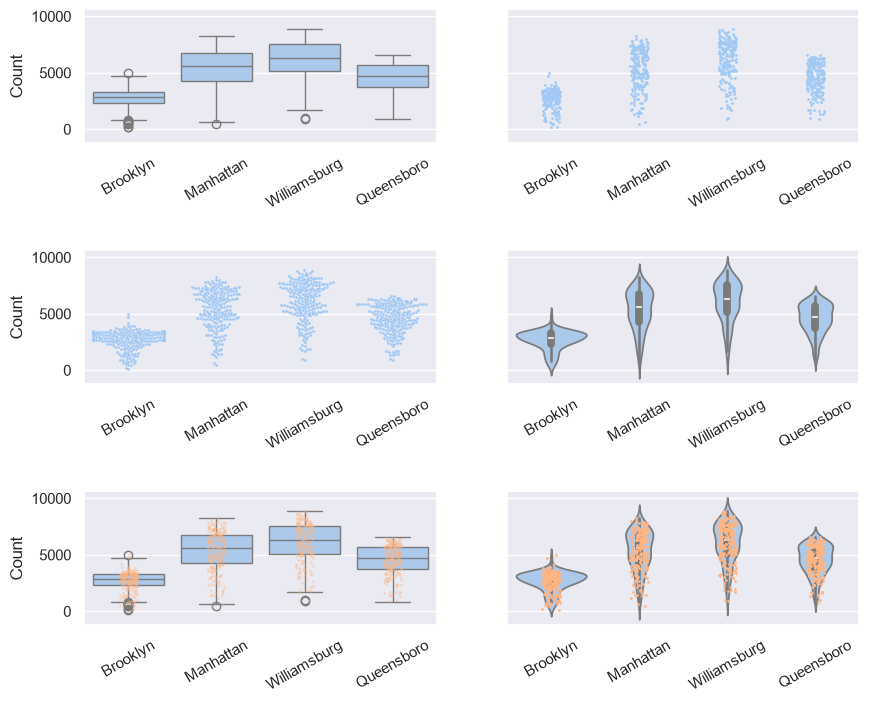

In [38]:
sns.set_palette('pastel') # Available seaborn palette options include deep, muted, bright, pastel, dark, and colorblind.

df = pd.melt(NY_bicycle_ts,
             id_vars=['Day','High_Temp_F'], 
             value_vars=['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']
            )
df.columns=['Day','Temperature','Bridge','Count']
df['Bridge'] = df['Bridge'].str.replace('_Bridge', '', regex=False) # Remove the suffix to simplify values in the "Bridge" column.


fig, ax = plt.subplots(3, 2,
                       sharey=True,
                       figsize=(10,8)
                      )


sns.boxplot(x='Bridge',
            y='Count',
            data=df,
            ax=ax[0][0]
           )
ax[0][0].set_xlabel('')

sns.stripplot(x='Bridge',
              y='Count',
              data=df,
              ax=ax[0][1],
              size=2
             )
ax[0][1].set_xlabel('')


sns.swarmplot(x='Bridge',
              y='Count',
              data=df,
              ax=ax[1][0],
              size=2
             )
ax[1][0].set_xlabel('')

sns.violinplot(x='Bridge',
               y='Count',
               data=df,
               ax=ax[1][1]
              )
ax[1][1].set_xlabel('')


sns.boxplot(x='Bridge',
            y='Count',
            data=df,
            ax=ax[2][0]
           )
sns.stripplot(x='Bridge',
              y='Count',
              data=df,
              ax=ax[2][0],
              size=2,
              alpha=0.4
             )
ax[2][0].set_xlabel('')


sns.violinplot(x='Bridge',
               y='Count',
               data=df,
               ax=ax[2][1]
              )
sns.stripplot(x='Bridge',
              y='Count',
              data=df,
              ax=ax[2][1],
              size=2
             )
ax[2][1].set_xlabel('')

# Adjust the spacing between subplots
plt.subplots_adjust(hspace=0.8, wspace=0.2)

# Rotate the x-tick labels.
for axes in ax.flat:
    axes.set_xticklabels(axes.get_xticklabels(), rotation=30)

sns.set_theme(rc={'figure.figsize':(8,8)})

plt.show();

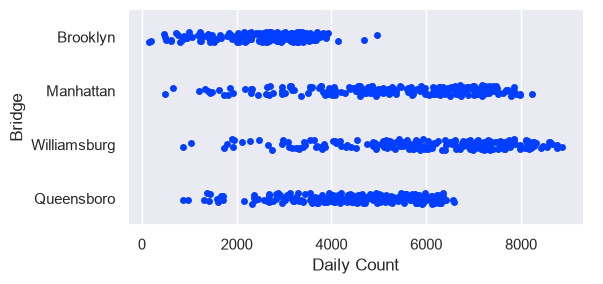

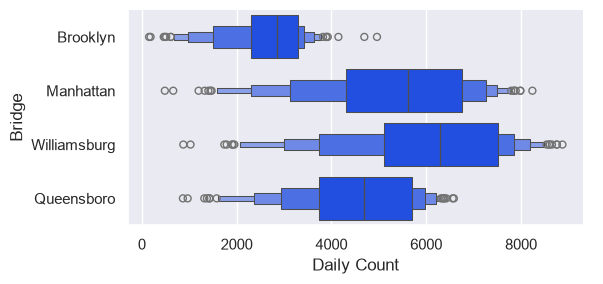

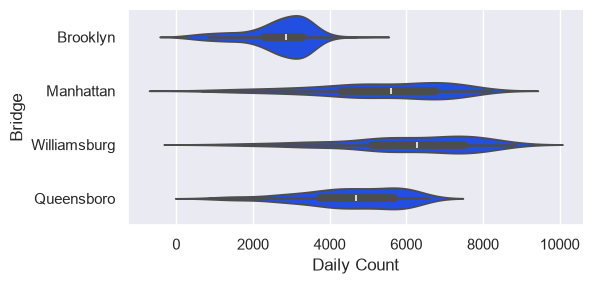

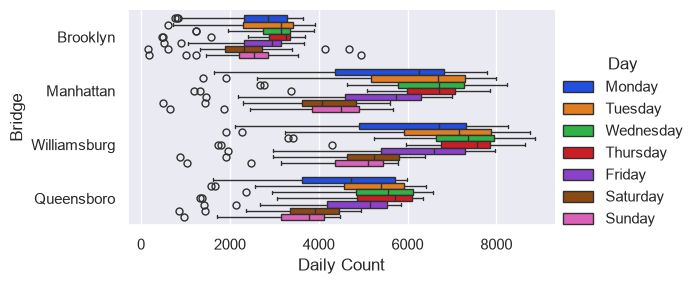

In [39]:
sns.set_palette('bright') # Available seaborn palette options include deep, muted, bright, pastel, dark, and colorblind.


df = pd.melt(NY_bicycle_ts,
             id_vars=['Day','High_Temp_F'], 
             value_vars=['Brooklyn_Bridge', 'Manhattan_Bridge', 'Williamsburg_Bridge','Queensboro_Bridge']
            )
df.columns=['Day','Temperature','Bridge','Daily Count']
df['Bridge'] = df['Bridge'].str.replace('_Bridge', '', regex=False) # Remove the suffix to simplify values in the "Bridge" column.


sns.catplot(data=df,
            x='Daily Count',
            y='Bridge', 
            kind='strip',
            height=3, 
            aspect=2
           )

sns.catplot(data=df,
            x='Daily Count',
            y='Bridge', 
            kind='boxen',
            height=3, 
            aspect=2
           )

sns.catplot(data=df,
            x='Daily Count',
            y='Bridge', 
            kind='violin',
            height=3, 
            aspect=2
           )

sns.catplot(data=df,
            x='Daily Count',
            y='Bridge', 
            kind='box',
            hue='Day',
            height=3, 
            aspect=2)

#sns.set_theme(rc={'figure.figsize':(6,16)})

plt.show();

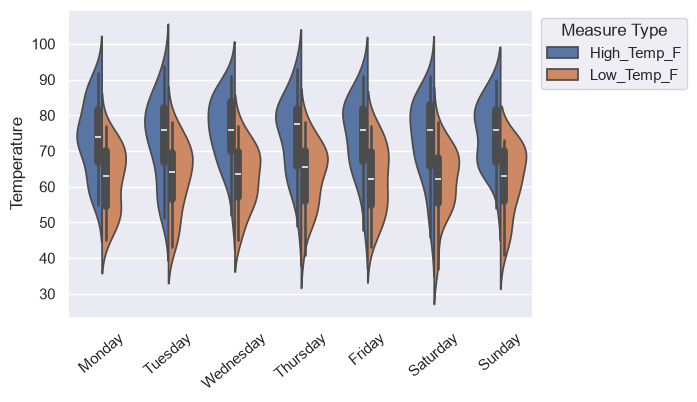

In [40]:
# In this example, we use split violin plots to compare high_temp_F and Low_Temp_F in terms of their distribution by days of week
sns.set_palette('deep') # Available seaborn palette options include deep, muted, bright, pastel, dark, and colorblind.

df = pd.melt(NY_bicycle_ts,
             id_vars=['Day'], 
             value_vars=['High_Temp_F','Low_Temp_F']
            )
df.columns=['Day of Week','Measure Type','Temperature']
df.head()

plt.figure(figsize=(6,4))
ax = sns.violinplot(x='Day of Week',
               y='Temperature',
               data=df, 
               hue='Measure Type',
               split=True # This is the setting for creating split violin plots
              )

sns.move_legend(ax, "upper left",bbox_to_anchor=(1, 1))

ax.set_xticklabels(ax.get_xticklabels(), rotation=40)
ax.set_xlabel('')

sns.set_theme(rc={'figure.figsize':(8,6)})

plt.show();

### Scatter and Joint Plots

Seaborn has multiple kinds of plots for showing the relationship between two variables:
- **scatterplot**: a two-dimensional plot that displays individual data points as markers, with one variable on the x-axis and another variable on the y-axis
- **jointplot**: a plot that combines univariate and bivariate views to summarize the relationship between two variables. Common `kind` options include `"reg"`, `"hex"`, `"kde"`, and `"hist"`.


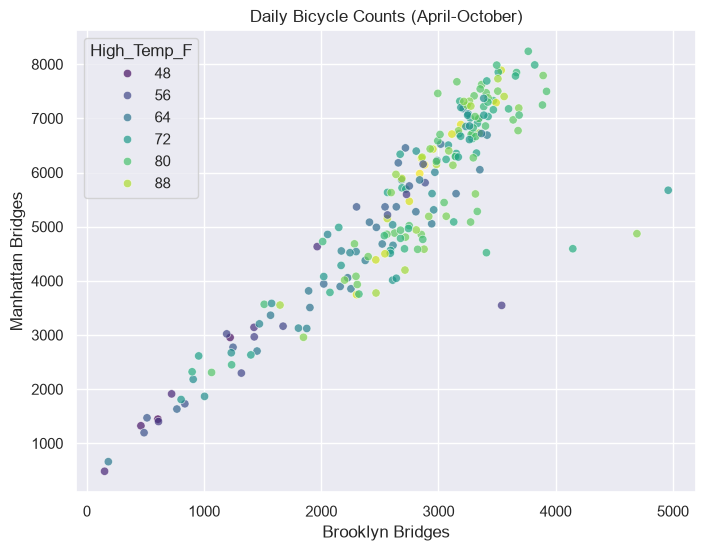

In [41]:
# Visualize the relationship between daily bicycle counts at two locations. Use color to indicate the day's high temperature.

plt.figure(figsize=(8,6))

sns.scatterplot(x=NY_bicycle_ts.Brooklyn_Bridge,
                y=NY_bicycle_ts.Manhattan_Bridge,
                hue=NY_bicycle_ts.High_Temp_F, # Color data points according to High_Temp_F.
                palette ='viridis',
                alpha=0.7,
                legend='brief' #"auto", "brief", "full", or False
               )


plt.xlabel('Brooklyn Bridges') 
plt.ylabel('Manhattan Bridges')

plt.title('Daily Bicycle Counts (April-October)')

sns.set_theme(rc={'figure.figsize':(6,6)})

plt.show();

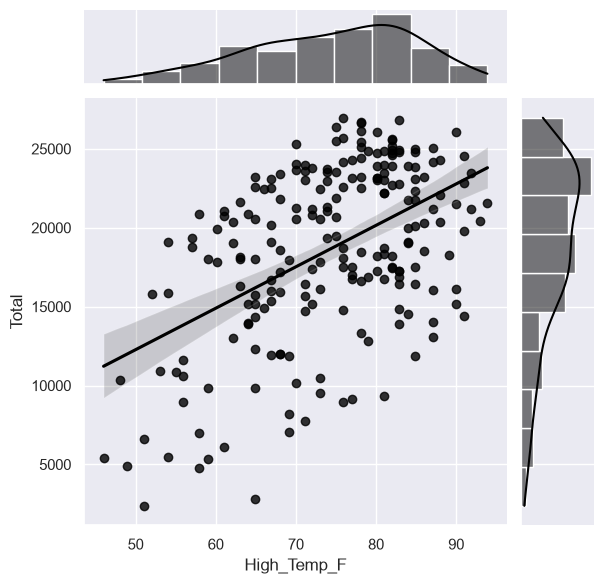

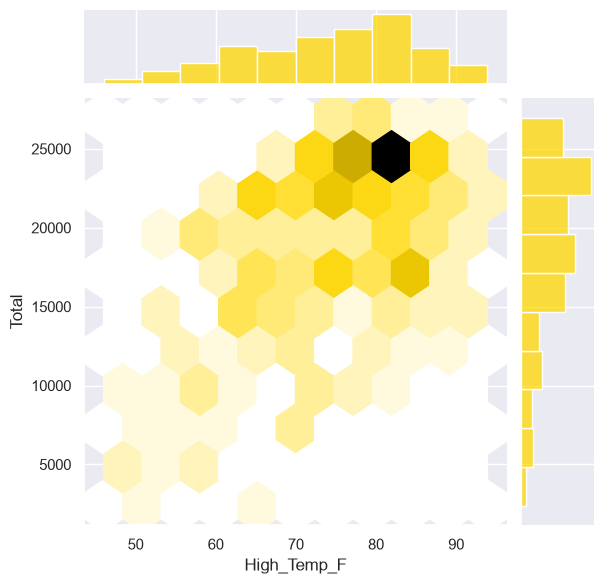

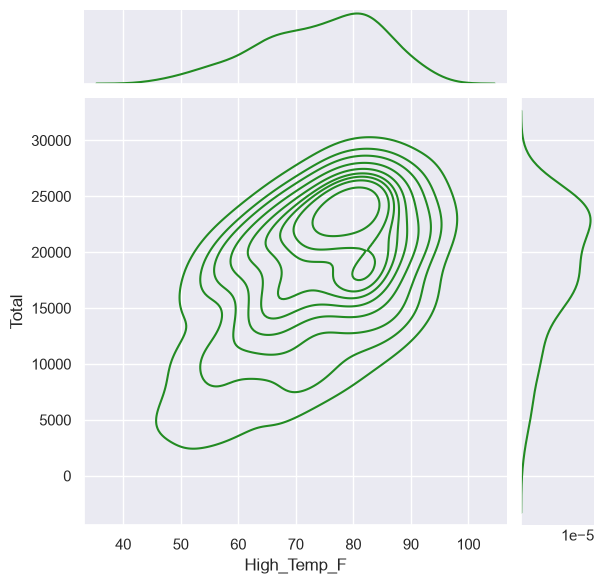

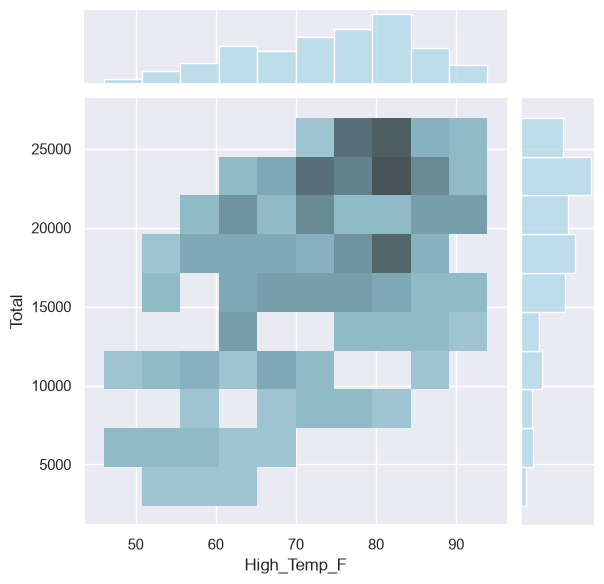

In [42]:
# jointplot supports different plot kinds.
sns.jointplot(data=NY_bicycle_ts,
              x='High_Temp_F',
              y='Total',
              color='black',
              kind='reg' # Show a linear regression fit and univariate KDE curves.
             ) 

sns.jointplot(data=NY_bicycle_ts,
              x='High_Temp_F',
              y='Total',
              color='gold',
              kind='hex' # hexagonal bins
             )

sns.jointplot(data=NY_bicycle_ts,
              x='High_Temp_F',
              y='Total',
              color='forestgreen',
              kind='kde') # Draw both bivariate and univariate KDEs.

sns.jointplot(data=NY_bicycle_ts,
              x='High_Temp_F',
              y='Total',
              color='lightblue',
              kind='hist') # Draw a joint histogram.

#sns.set_theme(rc={'figure.figsize': (10, 40)})

plt.show();

### Pairplot (Scatter Plot Matrix)

Seaborn has a **pairplot** function that can easily generate a scatter plot matrix.

Suggested practice:
1. Produce the scatter plot matrix for all numerical variables in the dataset.


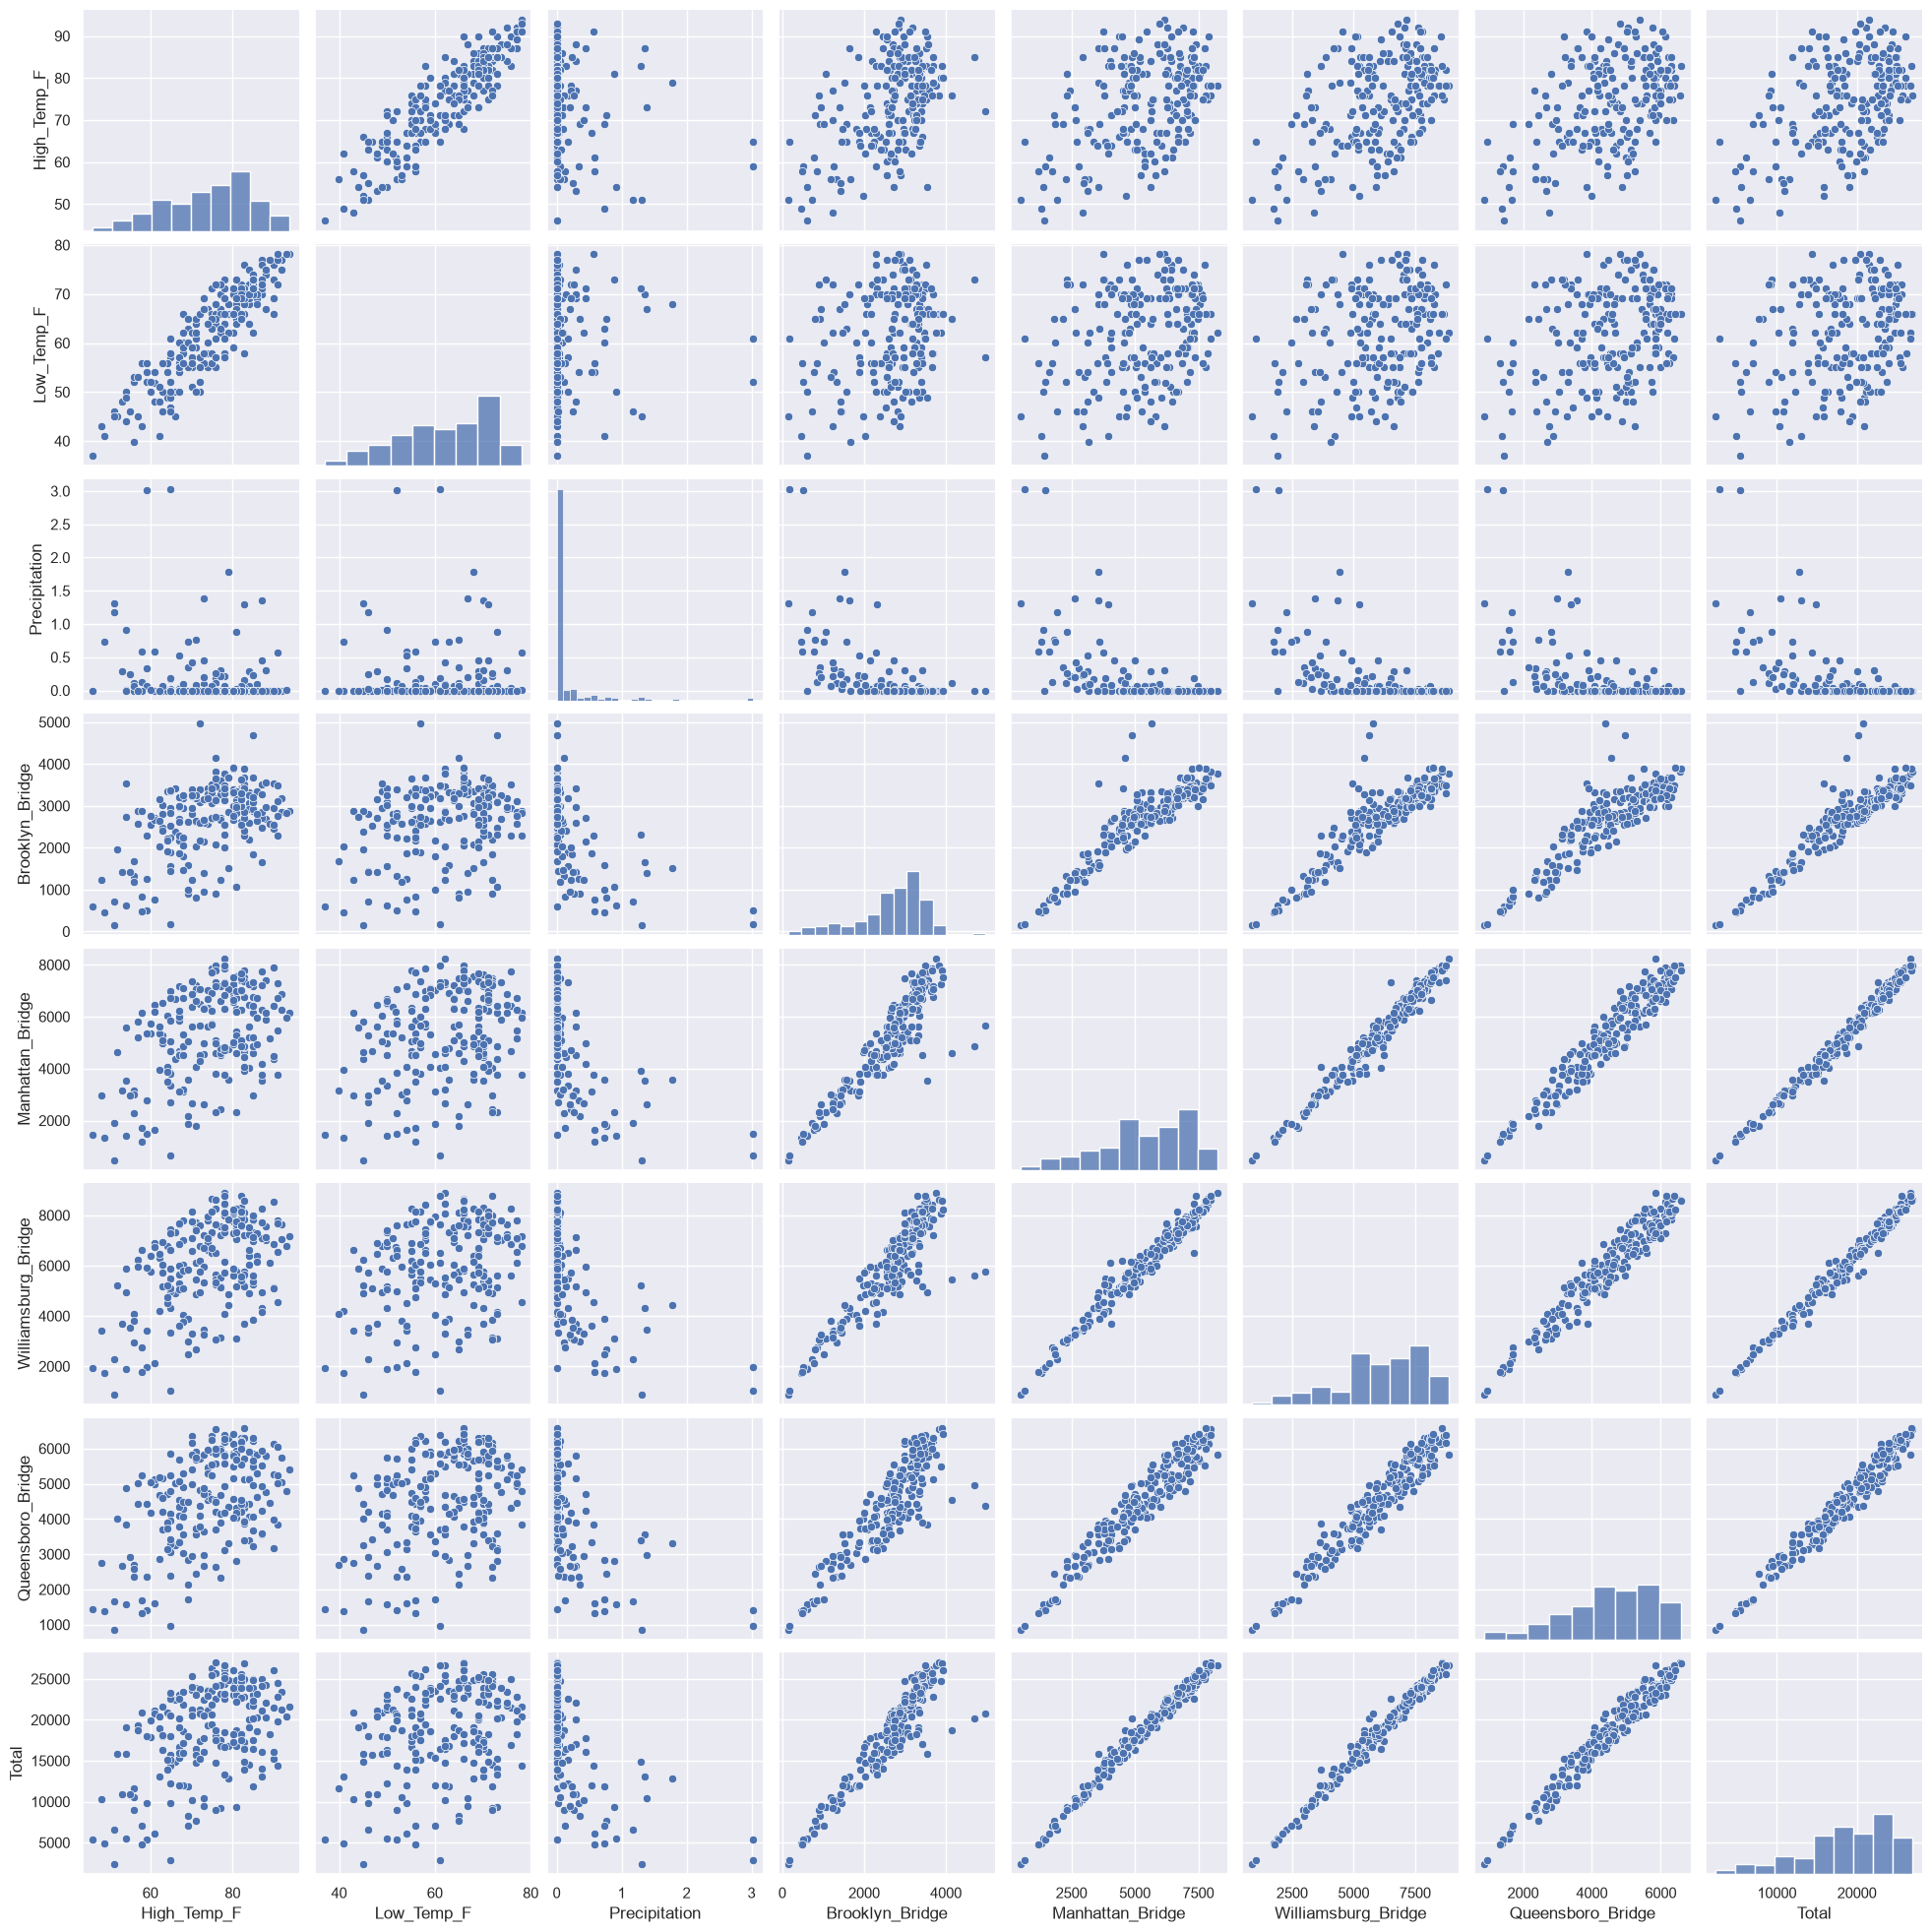

In [43]:
sns.pairplot(NY_bicycle_ts);

In [44]:
sns.reset_defaults() # sns.reset_defaults()